<div style="
  width:100%;
  border-radius:20px;
  padding:28px 30px;
  text-align:center;
  background:linear-gradient(135deg,#F8FBFF 0%, #EAF3FF 42%, #FFF7D6 76%, #F8FAFC 100%);
  border:1px solid rgba(0,113,206,0.18);
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Inter,Arial,sans-serif;
">
  <div style="
    display:inline-block;
    padding:6px 14px;
    border-radius:999px;
    border:1px solid rgba(0,113,206,0.18);
    background:rgba(255,255,255,0.94);
    font-size:12px;
    font-weight:700;
    color:#475569;
    margin-bottom:14px;
  ">
    Retail Analytics • Forecast Intelligence • Inventory Risk
  </div>

  <div style="
    font-size:32px;
    font-weight:900;
    line-height:1.18;
    margin-bottom:10px;
  ">
    <span style="color:#0071CE;">Walmart</span>
    <span style="color:#94A3B8;"> — </span>
    <span style="color:#0F172A;">Demand</span>
    <span style="color:#94A3B8;"> &times; </span>
    <span style="color:#FFC220;">Forecasting</span>
    <span style="color:#94A3B8;"> &times; </span>
    <span style="color:#004C91;">Inventory Intelligence</span>
  </div>

  <div style="
    font-size:15px;
    font-weight:600;
    color:#64748B;
  ">
    Store-Department Sales • Holiday Signals • Markdown Effects • WMAE Optimization
  </div>
</div>

![Walmart Retail Forecasting](https://github.com/rbyzk/MachineLearningProjects/blob/55a1e439c89320c617cb47c64a6f1cc24468b2c9/Walmart_Retail_Forecasting/Walmart.png?raw=true)

# Project Overview

This notebook builds an end-to-end forecasting workflow for Walmart weekly store sales. The objective is to forecast weekly sales at the **Store + Department + Date** level and translate model performance into business-readable decisions around demand risk, promotional sensitivity, forecast uncertainty, and inventory planning.

Retail demand forecasting is challenging because sales behavior changes across stores, departments, seasons, holidays, and markdown periods. A single aggregated sales trend is not enough to explain operational demand. Each store-department combination can have a different sales rhythm, holiday response, and level of promotional sensitivity.

The analysis follows a decision-support structure:

**business framing → data understanding → executive KPIs → diagnostic EDA → feature engineering → validation strategy → forecasting models → uncertainty analysis → inventory risk actions → executive conclusions**

This project is designed to answer a practical set of retail forecasting questions:

- How do weekly sales change across stores, departments, years, and holiday periods?
- Which store-department combinations drive the largest sales volume?
- How do markdowns and holiday weeks affect demand behavior and forecast error?
- Which baseline and machine learning models provide reliable forecast performance?
- Where is forecast risk concentrated across segments, weeks, and promotional periods?
- How can forecast uncertainty support inventory, replenishment, and safety-stock decisions?


<div style="background:linear-gradient(90deg,#eff6ff 0%,#fff8db 52%,#f8fafc 100%); padding:18px 22px; border-radius:16px; margin-bottom:14px; border:1px solid rgba(148,163,184,.18);">
  <div style="font-size:18px; font-weight:900; letter-spacing:.03em; text-transform:uppercase; color:#0071CE;">
    TL;DR – RETAIL DEMAND INTELLIGENCE AT A GLANCE
  </div>
  <div style="font-size:13.5px; margin-top:6px; color:#334155; line-height:1.6;">
    A practical forecasting and decision-support workflow for understanding Walmart demand patterns, evaluating forecast performance, measuring uncertainty, and connecting model outputs to inventory actions.
  </div>
</div>

<table style="width:100%; border-collapse:separate; border-spacing:14px;">
  <tr>
    <td style="width:33.33%; vertical-align:top; background:#eff6ff; border:1px solid #dbeafe; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#0071CE; margin-bottom:8px;">📊 Scope of the Analysis</div>
      <div style="font-size:13px; color:#334155; line-height:1.7;">
        • Store + Department + Date level sales forecasting<br>
        • Holiday, markdown, store, department, and seasonal demand signals<br>
        • Baseline, interpretable, machine learning, tuned, segment-specific, and quantile models<br>
        • Forecast diagnostics, watchlists, and inventory risk actions
      </div>
    </td>

<td style="width:33.33%; vertical-align:top; background:#fff8db; border:1px solid #fde68a; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#B77900; margin-bottom:8px;">💡 Main Reading</div>
      <div style="font-size:13px; color:#713F12; line-height:1.7;">
        • Demand changes by store, department, week, holiday context, and markdown activity<br>
        • WMAE emphasizes holiday errors because they carry higher operational risk<br>
        • Quantile intervals show where uncertainty is high<br>
        • Watchlists translate forecast risk into replenishment and safety-stock review priorities
      </div>
    </td>

<td style="width:33.33%; vertical-align:top; background:#f8fafc; border:1px solid #e2e8f0; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#004C91; margin-bottom:8px;">🔍 Where to Look</div>
      <div style="font-size:13px; color:#334155; line-height:1.7;">
        • <a href="#4-executive-kpi-snapshot" style="color:#0071CE; text-decoration:none;">Executive KPIs</a> for the high-level retail snapshot<br>
        • <a href="#5-diagnostic-eda" style="color:#0071CE; text-decoration:none;">Diagnostic EDA</a> for demand signals<br>
        • <a href="#12-main-machine-learning-forecasting-model" style="color:#0071CE; text-decoration:none;">Main ML Model</a> for full-data forecasting<br>
        • <a href="#15-quantile-forecasting" style="color:#0071CE; text-decoration:none;">Quantile Forecasting</a> for uncertainty intervals<br>
        • <a href="#18-inventory-action-layer" style="color:#0071CE; text-decoration:none;">Inventory Action Layer</a> for stock-risk decisions
      </div>
    </td>
  </tr>
</table>

<div style="
  background:#ffffff;
  border-radius:14px;
  padding:16px 20px;
  border:1px solid #e5e7eb;
  margin-top:10px;
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Inter,Arial,sans-serif;
">
  <div style="font-size:17px; font-weight:700; color:#0F172A; margin-bottom:10px;">
    📚 Notebook Roadmap
  </div>

  <ul style="margin-top:8px; padding-left:20px; line-height:1.55;">

<li>
      <a href="#0-setup--theme" style="color:#0071CE; text-decoration:none; font-weight:500;">
        0. 🧰 Setup & Theme
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Imports, warning control, Walmart-inspired theme, helper functions, and reusable display utilities
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#1-business-context" style="color:#0071CE; text-decoration:none; font-weight:500;">
        1. 🎯 Business Context
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Forecasting objective, Store + Department + Date detail level, WMAE metric, and decision framing
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#2-dataset-intake" style="color:#0071CE; text-decoration:none; font-weight:500;">
        2. 📊 Dataset Intake
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Raw files, schema review, missingness, sample records, and feature dictionary through tabbed tables
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#3-data-preparation--quality-gate" style="color:#0071CE; text-decoration:none; font-weight:500;">
        3. 🧹 Data Preparation & Quality Gate
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Data merging, markdown preparation, negative-sales handling, missing-value treatment, and target preparation
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#4-executive-kpi-snapshot" style="color:#0071CE; text-decoration:none; font-weight:500;">
        4. 📈 Executive KPI Snapshot
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        High-level business metrics for total sales, store coverage, department coverage, holiday share, markdown coverage, and volatility
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#5-diagnostic-eda" style="color:#0071CE; text-decoration:none; font-weight:500;">
        5. 🔍 Diagnostic EDA
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Sales timeline, holiday peaks, markdown behavior, store type performance, department concentration, and Store-Department heatmaps
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#6-time-series-analysis" style="color:#0071CE; text-decoration:none; font-weight:500;">
        6. 📉 Time Series Analysis
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Overall sales decomposition and selected high-volume Store-Department diagnostics
      </span>
    </li>

 <li style="margin-top:7px;">
      <a href="#7-feature-engineering" style="color:#0071CE; text-decoration:none; font-weight:500;">
        7. 🏗️ Feature Engineering
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Calendar features, holiday signals, markdown intensity, lag variables, rolling statistics, economic features, and ABC segmentation
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#8-validation-strategy-and-metrics" style="color:#0071CE; text-decoration:none; font-weight:500;">
        8. 🧪 Validation Strategy & Metrics
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Time-based validation, WMAE framework, supporting metrics, and leakage-aware historical statistics
      </span>
    </li>

 <li style="margin-top:7px;">
      <a href="#9-baseline-models" style="color:#0071CE; text-decoration:none; font-weight:500;">
        9. 📌 Baseline Models
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Naive, moving average, and seasonal reference models that define the minimum performance benchmark
      </span>
    </li>

 <li style="margin-top:7px;">
      <a href="#10-prophet-benchmark" style="color:#0071CE; text-decoration:none; font-weight:500;">
        10. 🔮 Prophet Benchmark
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Interpretable trend and seasonality benchmark for a selected high-volume Store-Department series
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#11-sarima-benchmark" style="color:#0071CE; text-decoration:none; font-weight:500;">
        11. 📐 SARIMA Benchmark
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Classical statistical time-series benchmark for the selected Store-Department series
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#12-main-machine-learning-forecasting-model" style="color:#0071CE; text-decoration:none; font-weight:500;">
        12. 🤖 Main ML Forecasting Model
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Full-data LightGBM or fallback model using engineered retail demand signals
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#13-wmae-targeted-hyperparameter-tuning" style="color:#0071CE; text-decoration:none; font-weight:500;">
        13. 🎛️ WMAE-Targeted Tuning
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Hyperparameter search ranked directly by validation WMAE
      </span>
    </li>

 <li style="margin-top:7px;">
      <a href="#14-store-department-segment-model-strategy" style="color:#0071CE; text-decoration:none; font-weight:500;">
        14. 🧩 Segment Model Strategy
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Separate model strategy for A/B/C Store-Department sales segments and comparison against the global model
      </span>
    </li>

   <li style="margin-top:7px;">
      <a href="#15-quantile-forecasting" style="color:#0071CE; text-decoration:none; font-weight:500;">
        15. 📦 Quantile Forecasting
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Prediction intervals, uncertainty coverage, and Q05-Q95 risk interpretation
      </span>
    </li>

  <li style="margin-top:7px;">
      <a href="#16-future-forecast-generation" style="color:#0071CE; text-decoration:none; font-weight:500;">
        16. 📝 Future Forecast Generation  
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Test feature preparation, future sales prediction, and forecast file generation
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#17-forecast-diagnostics-and-watchlist" style="color:#0071CE; text-decoration:none; font-weight:500;">
        17. 🚦 Forecast Diagnostics & Watchlist
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Actual vs predicted view, residual analysis, error-rate diagnostics, high-risk rows, and paired error comparison
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#18-inventory-action-layer" style="color:#0071CE; text-decoration:none; font-weight:500;">
        18. 📦 Inventory Action Layer
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Translation of forecast uncertainty and error risk into replenishment and safety-stock review actions
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#19-production-readiness-and-reproducibility-layer" style="color:#0071CE; text-decoration:none; font-weight:500;">
        19. 🛠️ Production Readiness
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Configuration export, artifact saving, smoke tests, module templates, and batch prediction interface
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#20-summary-assessment" style="color:#0071CE; text-decoration:none; font-weight:500;">
        20. 🧾 Key Findings and Business Outcomes
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Main demand insights, forecasting learnings, uncertainty findings, and inventory-oriented business outcomes
      </span>
    </li>

<li style="margin-top:7px;">
      <a href="#21-executive-conclusions" style="color:#0071CE; text-decoration:none; font-weight:500;">
        21. 🚀 Executive Conclusions
      </a><br>
      <span style="font-size:13px; color:#4b5563;">
        Final business reading, model strategy, forecast-risk interpretation, and inventory-oriented action summary
      </span>
    </li>

# 0. Setup & Theme

This section prepares the notebook environment, suppresses unnecessary warnings, defines a consistent Walmart-inspired visual theme, and creates reusable display functions for KPI cards, tabbed tables, charts, and output comments.

In [1]:
import os
import glob
import json
import logging
import warnings
import contextlib
import io
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML, Markdown

from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import joblib
    joblib_available = True
except Exception:
    joblib_available = False

warnings.filterwarnings("ignore")

In [2]:
for logger_name in [
    "cmdstanpy",
    "prophet",
    "fbprophet",
    "lightgbm",
    "xgboost",
    "statsmodels",
    "matplotlib"
]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)
    logging.getLogger(logger_name).propagate = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)

sns.set_theme(style="whitegrid")

@contextlib.contextmanager
def silent_output():
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield


THEME = {
    "blue": "#0071CE",
    "blue_dark": "#004C91",
    "blue_mid": "#2F80ED",
    "blue_soft": "#EAF3FF",
    "yellow": "#FFC220",
    "yellow_soft": "#FFF4C7",
    "gray": "#6B7280",
    "gray_dark": "#374151",
    "gray_soft": "#F3F4F6",
    "slate": "#0F172A",
    "white": "#FFFFFF",
    "danger": "#E76F51",
    "success": "#2A9D8F"
}

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["font.family"] = "DejaVu Sans"

## 0.1 Configuration and Logging

This notebook keeps key modelling constants in one configuration object. In a production repository, the same object can be moved to `config.yaml` or `config.py`. Logging is also initialized here so long-running model steps, tuning runs, and artifact exports can be tracked without relying on scattered print statements.

In [3]:
PROJECT_CONFIG = {
    "random_state": 42,
    "validation_weeks": 26,
    "rolling_validation": {
        "n_splits": 5,
        "valid_weeks": 8,
        "min_train_weeks": 52
    },
    "lag_weeks": [1, 2, 4, 8, 12, 52],
    "rolling_windows": [4, 8, 12],
    "segment_thresholds": {
        "A_share": 0.80,
        "B_share": 0.95
    },
    "quantile_alphas": [0.05, 0.50, 0.95],
    "inventory_risk_thresholds": {
        "low": 0.20,
        "medium": 0.50
    }
}

ARTIFACT_DIR = Path("walmart_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

logger = logging.getLogger("walmart_forecasting")
logger.setLevel(logging.ERROR)
logger.propagate = False

if not logger.handlers:
    logger.addHandler(logging.NullHandler())

with open(ARTIFACT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(PROJECT_CONFIG, f, indent=2)

logger.debug("Configuration and logging layer initialized.")

In [4]:
def money_fmt(x, pos=None):
    if pd.isna(x):
        return "—"
    if abs(x) >= 1_000_000_000:
        return f"${x/1_000_000_000:.1f}B"
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:,.0f}"

TABLE_CMAP = LinearSegmentedColormap.from_list("walmart_table_soft", ["#FFFFFF", "#EEF6FF", "#D7EAFD"])

def clean_axis(ax, xlabel=None, ylabel=None, xgrid=False):
    ax.set_facecolor("white")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.tick_params(colors=THEME["gray_dark"])
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=THEME["gray_dark"], labelpad=8)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=THEME["gray_dark"], labelpad=8)
    ax.grid(True, axis="x" if xgrid else "y", linestyle="--", linewidth=0.7, alpha=0.35, color="#CBD5E1")
    ax.grid(False, axis="y" if xgrid else "x")

def set_chart_title(ax, title, subtitle=None):
    ax.set_title(title, loc="left", color=THEME["slate"], pad=26, fontsize=13, fontweight="bold")
    if subtitle:
        ax.text(0, 1.025, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=8.8, color=THEME["gray"])

def output_note(text):
    display(Markdown(text))

def kpi_cards(items, columns=4):
    width = f"calc({100 / columns:.2f}% - 12px)"
    card_html = []
    for item in items:
        title = item.get("title", "")
        value = item.get("value", "")
        accent = item.get("accent", THEME["blue"])
        sub = item.get("note", item.get("sub", ""))
        card_html.append(f'''
        <div style="
            flex:0 0 {width};
            min-width:160px;
            border-radius:12px;
            border:1px solid rgba(15,23,42,0.08);
            padding:11px 13px;
            background:#FFFFFF;
            box-shadow:0 4px 10px rgba(15,23,42,0.05);
            box-sizing:border-box;
        ">
          <div style="width:32px;height:3px;border-radius:999px;background:{accent};margin-bottom:7px;"></div>
          <div style="font-size:10.5px;text-transform:uppercase;letter-spacing:.065em;color:{THEME['gray']};margin-bottom:3px;font-weight:700;">{title}</div>
          <div style="font-size:21px;font-weight:900;color:{THEME['slate']};line-height:1.15;margin-bottom:3px;">{value}</div>
          <div style="font-size:11px;color:{THEME['gray']};line-height:1.3;">{sub}</div>
        </div>
        ''')
    html = f'''
    <div style="
        display:flex;
        gap:12px;
        flex-wrap:wrap;
        align-items:stretch;
        margin:8px 0 16px 0;
        width:100%;
    ">
      {''.join(card_html)}
    </div>
    '''
    display(HTML(html))

def pretty_table(df, caption=None, n=20, precision=2, color_cols=None):
    show_df = df.head(n).copy()
    numeric_cols = show_df.select_dtypes(include=np.number).columns.tolist()
    color_cols = color_cols if color_cols is not None else numeric_cols[:4]

    styler = show_df.style.format(precision=precision, thousands=",", na_rep="—")
    if caption:
        styler = styler.set_caption(caption)

    if color_cols:
        valid_color_cols = [c for c in color_cols if c in show_df.columns and pd.api.types.is_numeric_dtype(show_df[c])]
        if valid_color_cols:
            styler = styler.background_gradient(cmap=TABLE_CMAP, subset=valid_color_cols, axis=0)

    styler = styler.set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "800"), ("font-size", "14px"), ("color", THEME["slate"]), ("text-align", "left"), ("padding", "4px 0 8px 0")]},
        {"selector": "th", "props": [("background-color", THEME["gray_soft"]), ("color", THEME["slate"]), ("font-weight", "800"), ("border", "1px solid #E5E7EB"), ("padding", "7px 8px"), ("white-space", "nowrap")]},
        {"selector": "td", "props": [("border", "1px solid #E5E7EB"), ("padding", "6px 8px"), ("color", THEME["slate"]), ("white-space", "nowrap")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "max-content"), ("min-width", "100%"), ("font-size", "11.5px")]}
    ])

    html = f'''
    <div style="width:100%; overflow-x:auto; margin:6px 0 14px 0;">
      {styler.to_html()}
    </div>
    '''
    display(HTML(html))

def df_tabs(tabs, title="Dataset Review"):
    tab_id = "tabs_" + str(abs(hash(title)))[:8]
    buttons = []
    panes = []
    for i, (label, frame, rows) in enumerate(tabs):
        active = "active" if i == 0 else ""
        pane_id = f"{tab_id}_{i}"
        table_html = frame.head(rows).to_html(index=False, border=0, classes="tab-table")
        buttons.append(f'<button class="tab-button {active}" onclick="open_{tab_id}(event, \'{pane_id}\')">{label}</button>')
        panes.append(f'<div id="{pane_id}" class="tab-pane {active}"><div style="overflow-x:auto;">{table_html}</div></div>')
    html = f'''
    <div style="margin:10px 0 18px 0;">
      <div style="font-weight:800;color:{THEME['slate']};font-size:15px;margin-bottom:8px;">{title}</div>
      <div id="{tab_id}" class="tab-wrapper">
        <div class="tab-bar">{''.join(buttons)}</div>
        <div class="tab-content">{''.join(panes)}</div>
      </div>
    </div>
    <style>
      #{tab_id}.tab-wrapper {{
        border:1px solid #E5E7EB;
        border-radius:12px;
        background:#FFFFFF;
        overflow:hidden;
      }}
      #{tab_id} .tab-bar {{
        display:flex;
        gap:6px;
        flex-wrap:wrap;
        padding:10px;
        border-bottom:1px solid #E5E7EB;
        background:#F9FAFB;
      }}
      #{tab_id} .tab-button {{
        border:1px solid #D1D5DB;
        background:#FFFFFF;
        color:{THEME['gray_dark']};
        font-size:12px;
        font-weight:800;
        padding:7px 13px;
        border-radius:999px;
        cursor:pointer;
      }}
      #{tab_id} .tab-button.active {{
        background:{THEME['blue']};
        color:white;
        border-color:{THEME['blue']};
      }}
      #{tab_id} .tab-content {{
        padding:12px;
        overflow-x:auto;
        background:#FFFFFF;
      }}
      #{tab_id} .tab-pane {{
        display:none;
      }}
      #{tab_id} .tab-pane.active {{
        display:block;
      }}
      #{tab_id} .tab-table {{
        border-collapse:collapse;
        width:max-content;
        min-width:100%;
        font-size:11.5px;
        color:{THEME['slate']};
      }}
      #{tab_id} .tab-table th {{
        background:{THEME['gray_soft']};
        padding:8px;
        border:1px solid #E5E7EB;
        text-align:left;
        white-space:nowrap;
      }}
      #{tab_id} .tab-table td {{
        padding:7px 8px;
        border:1px solid #E5E7EB;
        white-space:nowrap;
      }}
    </style>
    <script>
      function open_{tab_id}(evt, paneId) {{
        const root = document.getElementById("{tab_id}");
        const panes = root.getElementsByClassName("tab-pane");
        const buttons = root.getElementsByClassName("tab-button");
        for (let p of panes) p.classList.remove("active");
        for (let b of buttons) b.classList.remove("active");
        document.getElementById(paneId).classList.add("active");
        evt.currentTarget.classList.add("active");
      }}
    </script>
    '''
    display(HTML(html))

def table_grid(tables, title=None):
    blocks = []
    for caption, frame, rows in tables:
        html = frame.head(rows).style.format(precision=2, thousands=",", na_rep="—").set_caption(caption).set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "800"), ("font-size", "13px"), ("text-align", "left"), ("padding", "3px 0 8px 0")]},
            {"selector": "th", "props": [("background-color", THEME["gray_soft"]), ("padding", "7px"), ("border", "1px solid #E5E7EB"), ("white-space", "nowrap")]},
            {"selector": "td", "props": [("padding", "6px 7px"), ("border", "1px solid #E5E7EB"), ("white-space", "nowrap")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "max-content"), ("min-width", "100%"), ("font-size", "11.5px")]}
        ]).to_html()
        blocks.append(f'<div style="flex:1 1 360px; min-width:320px; overflow-x:auto;">{html}</div>')
    heading = f'<div style="font-weight:800;color:{THEME["slate"]};font-size:15px;margin-bottom:8px;">{title}</div>' if title else ""
    display(HTML(f'''
    <div style="margin:8px 0 16px 0;">
      {heading}
      <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:flex-start;">
        {''.join(blocks)}
      </div>
    </div>
    '''))

display(HTML(f"""
<div style="
    margin: 10px 0 18px 0;
    padding: 12px 16px;
    border-radius: 12px;
    border: 1px solid #D1D5DB;
    background: #F8FAFC;
    color: {THEME["slate"]};
    font-size: 13px;
    line-height: 1.55;
">
    <b style="color:{THEME["blue"]};">Theme setup completed.</b>
    The notebook will use a consistent Walmart-inspired blue, yellow, and gray visual system for KPI cards, tables, and charts.
</div>
"""))

# 1. Business Context

The business problem is to forecast weekly sales for each store and department. Instead of using the technical term “granularity”, this notebook uses **forecasting detail level**: the level at which predictions are produced.

The forecasting detail level is:

**Store + Department + Date**

This means that each row represents one weekly sales forecast for one department inside one Walmart store.

The evaluation metric is **WMAE**, which penalizes holiday week errors more heavily. This aligns with retail operations because holiday weeks are high-demand, high-risk periods where forecast errors can create stockouts, lost sales, or unnecessary inventory buildup.

# 2. Dataset Intake

This section loads the raw train, test, features and stores files. The dataset is reviewed through horizontal tabs so that structure, missingness, samples, and feature definitions remain organized.

In [5]:
DATA_PATH = "/kaggle/input/datasets/aslanahmedov/walmart-sales-forecast"

train_path = os.path.join(DATA_PATH, "train.csv")
test_path = os.path.join(DATA_PATH, "test.csv")
features_path = os.path.join(DATA_PATH, "features.csv")
stores_path = os.path.join(DATA_PATH, "stores.csv")

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)
features_raw = pd.read_csv(features_path)
stores_raw = pd.read_csv(stores_path)

for frame in [train_raw, test_raw, features_raw]:
    frame["Date"] = pd.to_datetime(frame["Date"])

In [6]:
snapshot = pd.DataFrame({
    "Dataset": ["train", "test", "features", "stores"],
    "Rows": [
        len(train_raw),
        len(test_raw),
        len(features_raw),
        len(stores_raw)
    ],
    "Columns": [
        train_raw.shape[1],
        test_raw.shape[1],
        features_raw.shape[1],
        stores_raw.shape[1]
    ],
    "Missing Cells": [
        train_raw.isna().sum().sum(),
        test_raw.isna().sum().sum(),
        features_raw.isna().sum().sum(),
        stores_raw.isna().sum().sum()
    ]
})

columns_review = pd.concat([
    pd.DataFrame({
        "Dataset": "train",
        "Column": train_raw.columns,
        "Type": train_raw.dtypes.astype(str).values,
        "Non Null": train_raw.notna().sum().values,
        "Unique": train_raw.nunique(dropna=False).values
    }),
    pd.DataFrame({
        "Dataset": "test",
        "Column": test_raw.columns,
        "Type": test_raw.dtypes.astype(str).values,
        "Non Null": test_raw.notna().sum().values,
        "Unique": test_raw.nunique(dropna=False).values
    }),
    pd.DataFrame({
        "Dataset": "features",
        "Column": features_raw.columns,
        "Type": features_raw.dtypes.astype(str).values,
        "Non Null": features_raw.notna().sum().values,
        "Unique": features_raw.nunique(dropna=False).values
    }),
    pd.DataFrame({
        "Dataset": "stores",
        "Column": stores_raw.columns,
        "Type": stores_raw.dtypes.astype(str).values,
        "Non Null": stores_raw.notna().sum().values,
        "Unique": stores_raw.nunique(dropna=False).values
    })
], ignore_index=True)

dataset_row_counts = {
    "train": train_raw.shape[0],
    "test": test_raw.shape[0],
    "features": features_raw.shape[0],
    "stores": stores_raw.shape[0]
}

missing_review = columns_review.copy()
missing_review["Missing"] = (
    missing_review["Dataset"].map(dataset_row_counts)
    - missing_review["Non Null"]
)

missing_review["Missing Rate"] = (
    missing_review["Missing"]
    / missing_review["Dataset"].map(dataset_row_counts)
)

feature_dictionary = pd.DataFrame({
    "Feature": [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday",
        "Type",
        "Size",
        "Temperature",
        "Fuel_Price",
        "MarkDown1-5",
        "CPI",
        "Unemployment"
    ],
    "Meaning": [
        "Store identifier",
        "Department identifier",
        "Weekly date",
        "Weekly sales target available in train data",
        "Holiday week flag",
        "Store type",
        "Store size",
        "Local temperature",
        "Fuel price",
        "Promotional markdown variables",
        "Consumer price index",
        "Unemployment rate"
    ]
})

df_tabs([
    ("Snapshot", snapshot, 10),
    ("Columns", columns_review, 80),
    ("Missing", missing_review.sort_values("Missing", ascending=False), 80),
    ("Feature Dictionary", feature_dictionary, 20),
    ("Train Sample", train_raw.head(8), 8),
    ("Test Sample", test_raw.head(8), 8),
    ("Features Sample", features_raw.head(8), 8),
    ("Stores Sample", stores_raw.head(8), 8)
], title="Raw Dataset Intake")

The train data contains historical weekly sales, while the test data contains future Store-Department-Date rows to forecast. Markdown columns have meaningful missingness and should be treated as promotional absence unless evidence suggests otherwise.

# 3. Data Preparation & Quality Gate

The data is merged into modeling-ready train and test frames. Negative sales are preserved in the raw target but clipped to zero for the clean modeling target. Markdown values are filled with zero because missing markdowns generally indicate no observed promotional event.

In [7]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

feature_store = features_raw.merge(stores_raw, on="Store", how="left")

data = (
    train_raw
    .merge(feature_store, on=["Store", "Date", "IsHoliday"], how="left")
    .sort_values(["Store", "Dept", "Date"])
    .reset_index(drop=True)
)

test_data = (
    test_raw
    .merge(feature_store, on=["Store", "Date", "IsHoliday"], how="left")
    .sort_values(["Store", "Dept", "Date"])
    .reset_index(drop=True)
)

data["Weekly_Sales_Raw"] = data["Weekly_Sales"]
data["Weekly_Sales_Clean"] = data["Weekly_Sales"].clip(lower=0)
data["Negative_Sales_Flag"] = (data["Weekly_Sales"] < 0).astype(int)

for col in markdown_cols:
    data[col] = data[col].fillna(0)
    test_data[col] = test_data[col].fillna(0)

for frame in [data, test_data]:
    frame["CPI"] = frame.groupby("Store")["CPI"].transform(lambda x: x.ffill().bfill())
    frame["Unemployment"] = frame.groupby("Store")["Unemployment"].transform(lambda x: x.ffill().bfill())

quality_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Duplicate Store-Dept-Date Rows", "Negative Sales Rows", "Remaining Missing Cells"],
    "Value": [
        len(data),
        data.shape[1],
        data.duplicated(["Store", "Dept", "Date"]).sum(),
        int(data["Negative_Sales_Flag"].sum()),
        int(data.isna().sum().sum())
    ]
})

pretty_table(quality_summary, "Data Quality Summary", 10)

,Metric,Value
0,Rows,"421,570"
1,Columns,19
2,Duplicate Store-Dept-Date Rows,0
3,Negative Sales Rows,"1,285"
4,Remaining Missing Cells,0


The merged dataset is ready for forecasting. Negative sales are rare operational anomalies and are handled through a clean target. Markdown missingness is transformed into zero-valued promotional absence, while CPI and unemployment are filled within each store.

# 4. Executive KPI Snapshot

The KPI snapshot provides a compact executive view of the forecasting problem: total sales volume, store and department coverage, holiday exposure, markdown coverage, and sales volatility.

In [8]:
total_sales = data["Weekly_Sales_Clean"].sum()
avg_sales = data["Weekly_Sales_Clean"].mean()
holiday_sales_share = data.loc[data["IsHoliday"], "Weekly_Sales_Clean"].sum() / total_sales
markdown_coverage = data[markdown_cols].gt(0).any(axis=1).mean()
volatility = data["Weekly_Sales_Clean"].std() / data["Weekly_Sales_Clean"].mean()
series_count = data[["Store", "Dept"]].drop_duplicates().shape[0]

kpi_cards([
    {"title": "Total Clean Sales", "value": money_fmt(total_sales), "note": "Sales after clipping negative values", "accent": THEME["blue"]},
    {"title": "Avg Weekly Sales", "value": money_fmt(avg_sales), "note": "Average at row level", "accent": THEME["blue_dark"]},
    {"title": "Stores", "value": f"{data['Store'].nunique():,}", "note": "Unique stores", "accent": THEME["gray_dark"]},
    {"title": "Departments", "value": f"{data['Dept'].nunique():,}", "note": "Unique departments", "accent": THEME["yellow"]},
    {"title": "Store-Dept Series", "value": f"{series_count:,}", "note": "Forecasting series", "accent": THEME["blue"]},
    {"title": "Holiday Sales Share", "value": f"{holiday_sales_share:.1%}", "note": "Sales from holiday weeks", "accent": THEME["yellow"]},
    {"title": "Markdown Coverage", "value": f"{markdown_coverage:.1%}", "note": "At least one markdown > 0", "accent": THEME["blue_mid"]},
    {"title": "Sales Volatility", "value": f"{volatility:.2f}", "note": "Std divided by mean", "accent": THEME["gray"]}
], columns=4)

The data covers many Store-Department series rather than a single aggregated sales stream. This confirms that the forecasting problem must be evaluated at a detailed operational level instead of relying on a single global average.

# 5. Diagnostic EDA

This section investigates demand signals before modeling. The goal is to understand when sales peak, how holiday weeks behave, how markdown activity aligns with sales, and which stores or departments dominate volume.

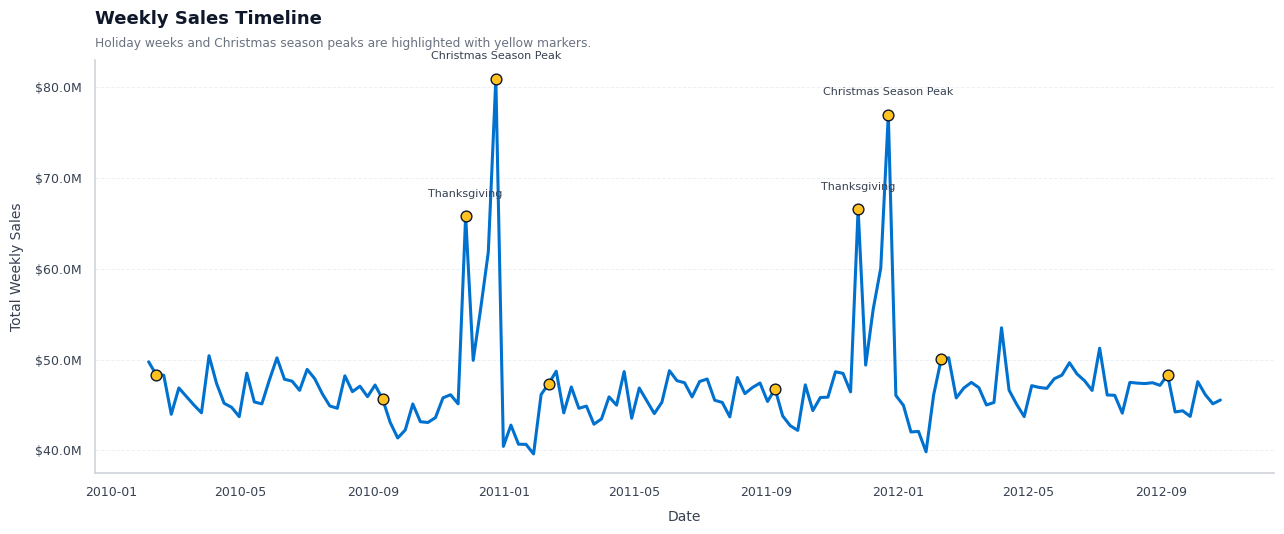

In [9]:
weekly_sales = (
    data.groupby("Date", as_index=False)
    .agg(Weekly_Sales=("Weekly_Sales_Clean", "sum"))
    .sort_values("Date")
)

holiday_events = pd.DataFrame({
    "Event": ["Super Bowl", "Labor Day", "Thanksgiving"] * 3,
    "Date": pd.to_datetime([
        "2010-02-12", "2010-09-10", "2010-11-26",
        "2011-02-11", "2011-09-09", "2011-11-25",
        "2012-02-10", "2012-09-07", "2012-11-23"
    ])
})

christmas_peaks = (
    weekly_sales[weekly_sales["Date"].dt.month.eq(12)]
    .assign(Year=lambda x: x["Date"].dt.year)
    .sort_values("Weekly_Sales", ascending=False)
    .groupby("Year", as_index=False)
    .head(1)
    .assign(Event="Christmas Season Peak")
    [["Event", "Date"]]
)

events = pd.concat([holiday_events, christmas_peaks], ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    color=THEME["blue"],
    linewidth=2.2
)

for _, row in events.iterrows():
    y = weekly_sales.loc[weekly_sales["Date"].eq(row["Date"]), "Weekly_Sales"]
    
    if len(y):
        ax.scatter(
            row["Date"],
            y.iloc[0],
            color=THEME["yellow"],
            edgecolor=THEME["slate"],
            s=60,
            zorder=4
        )
        
        if row["Event"] in ["Thanksgiving", "Christmas Season Peak"]:
            ax.annotate(
                row["Event"],
                (row["Date"], y.iloc[0]),
                xytext=(0, 14),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color=THEME["gray_dark"]
            )

ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))

set_chart_title(
    ax,
    "Weekly Sales Timeline",
    "Holiday weeks and Christmas season peaks are highlighted with yellow markers."
)

clean_axis(ax, xlabel="Date", ylabel="Total Weekly Sales")

plt.tight_layout()
plt.show()

Weekly sales show recurring peaks around key holiday periods, especially Thanksgiving and the Christmas shopping season. Since Christmas-related demand often peaks before the official holiday week, the chart highlights the highest December sales week as the Christmas Season Peak.

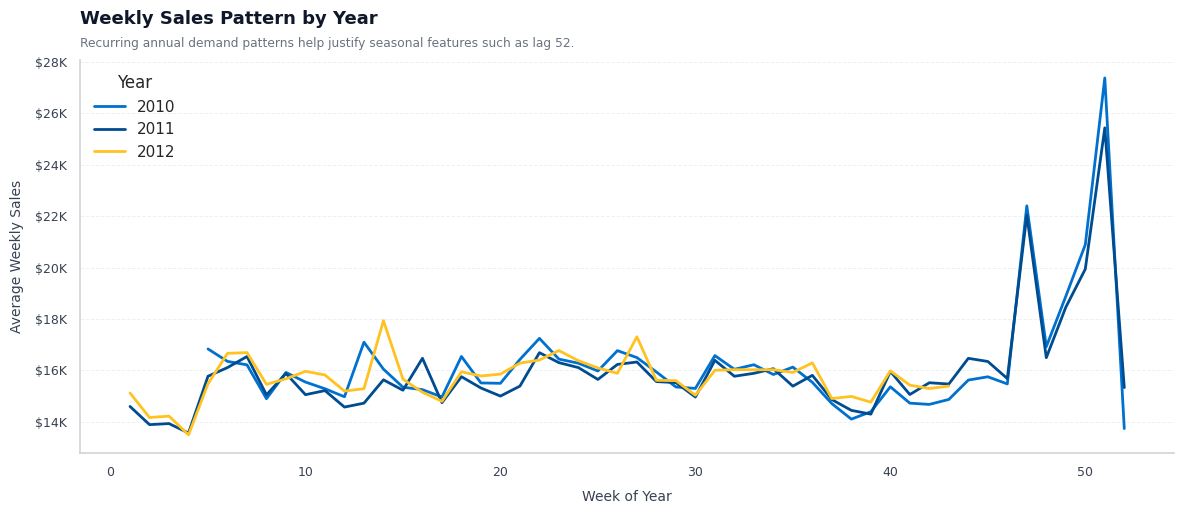

In [10]:
data["Year"] = data["Date"].dt.year
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)

year_week = data.groupby(["Year", "Week"], as_index=False).agg(Avg_Sales=("Weekly_Sales_Clean", "mean"))

fig, ax = plt.subplots(figsize=(12, 5.3))
palette = {2010: THEME["blue"], 2011: THEME["blue_dark"], 2012: THEME["yellow"]}
for year, frame in year_week.groupby("Year"):
    ax.plot(frame["Week"], frame["Avg_Sales"], linewidth=2.0, label=str(year), color=palette.get(year, THEME["gray"]))
ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Weekly Sales Pattern by Year", "Recurring annual demand patterns help justify seasonal features such as lag 52.")
clean_axis(ax, xlabel="Week of Year", ylabel="Average Weekly Sales")
ax.legend(frameon=False, title="Year")
plt.tight_layout()
plt.show()

Similar weekly patterns across years indicate that yearly seasonality is an important forecasting signal, supporting seasonal naive baselines, Prophet/SARIMA benchmarks, and calendar-based ML features.

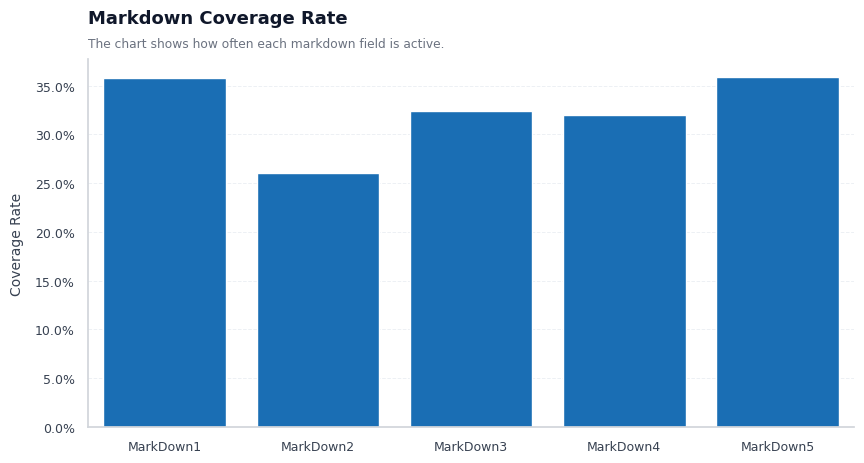

In [11]:
data["Total_MarkDown"] = data[markdown_cols].sum(axis=1)
data["Has_MarkDown"] = (data["Total_MarkDown"] > 0).astype(int)
data["Markdown_Count"] = (data[markdown_cols] > 0).sum(axis=1)

coverage = pd.DataFrame({
    "MarkDown": markdown_cols,
    "Coverage_Rate": [(data[c] > 0).mean() for c in markdown_cols]
})

weekly_md = data.groupby("Week", as_index=False).agg(
    Weekly_Sales=("Weekly_Sales_Clean", "sum"),
    Total_MarkDown=("Total_MarkDown", "sum")
)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
sns.barplot(data=coverage, x="MarkDown", y="Coverage_Rate", ax=ax, color=THEME["blue"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
set_chart_title(ax, "Markdown Coverage Rate", "The chart shows how often each markdown field is active.")
clean_axis(ax, xlabel="", ylabel="Coverage Rate")
plt.tight_layout()
plt.show()

Markdown coverage is uneven across markdown variables, which means promotion information should be treated as a sparse but potentially valuable demand signal.

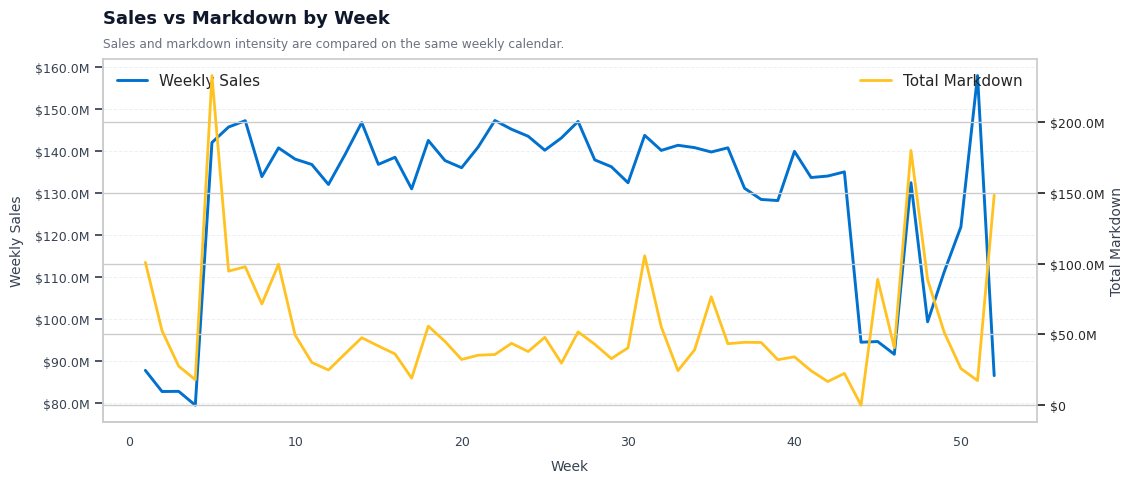

In [12]:
fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.plot(weekly_md["Week"], weekly_md["Weekly_Sales"], color=THEME["blue"], linewidth=2.1, label="Weekly Sales")
ax2 = ax.twinx()
ax2.plot(weekly_md["Week"], weekly_md["Total_MarkDown"], color=THEME["yellow"], linewidth=2.0, label="Total Markdown")
ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
ax2.yaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Sales vs Markdown by Week", "Sales and markdown intensity are compared on the same weekly calendar.")
clean_axis(ax, xlabel="Week", ylabel="Weekly Sales")
ax2.set_ylabel("Total Markdown", color=THEME["gray_dark"])
ax.legend(loc="upper left", frameon=False)
ax2.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

Sales and markdown activity move together in selected periods, but the relationship is not uniform; therefore, markdown should be modeled through amount, coverage, intensity, count, delayed effects, and holiday interaction features rather than as a single raw variable.

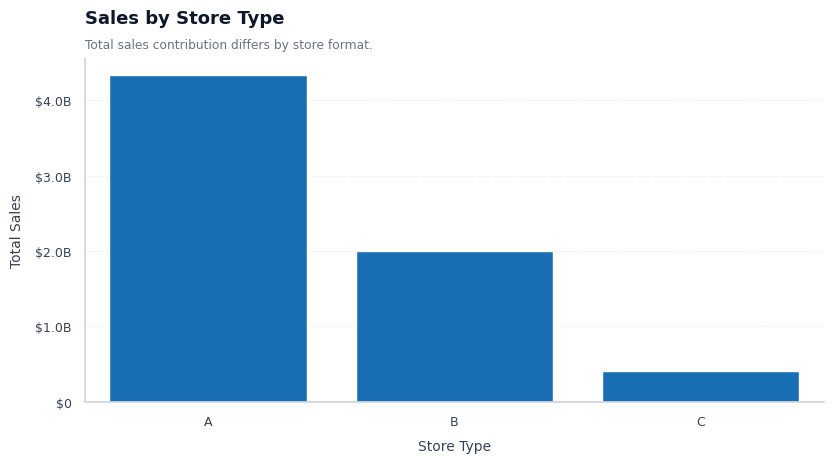

In [13]:
type_summary = data.groupby("Type", as_index=False).agg(
    Total_Sales=("Weekly_Sales_Clean", "sum"),
    Avg_Sales=("Weekly_Sales_Clean", "mean"),
    Store_Count=("Store", "nunique")
).sort_values("Total_Sales", ascending=False)

dept_summary = (
    data.groupby("Dept", as_index=False)
    .agg(Total_Sales=("Weekly_Sales_Clean", "sum"))
    .sort_values("Total_Sales", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(data=type_summary, x="Type", y="Total_Sales", ax=ax, color=THEME["blue"])
ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Sales by Store Type", "Total sales contribution differs by store format.")
clean_axis(ax, xlabel="Store Type", ylabel="Total Sales")
plt.tight_layout()
plt.show()

Store type and department structure reveal where sales volume is concentrated. High-volume formats and departments should receive closer model diagnostics because forecast errors in these groups carry larger business impact.

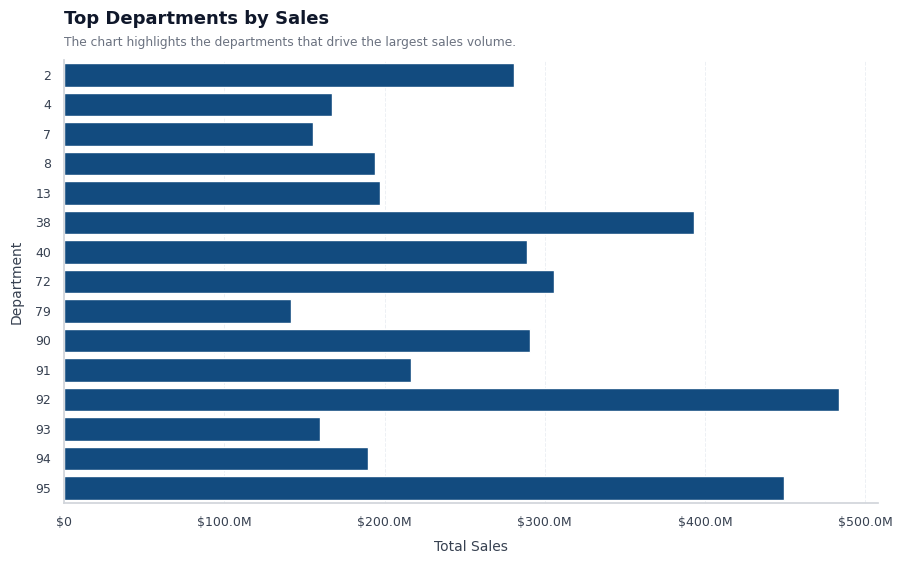

In [14]:
fig, ax = plt.subplots(figsize=(9.2, 5.8))
sns.barplot(data=dept_summary, y="Dept", x="Total_Sales", ax=ax, color=THEME["blue_dark"], orient="h")
ax.xaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Top Departments by Sales", "The chart highlights the departments that drive the largest sales volume.")
clean_axis(ax, xlabel="Total Sales", ylabel="Department", xgrid=True)
plt.tight_layout()
plt.show()

Department-level concentration confirms that a small set of departments carries a disproportionate share of revenue. These departments deserve stronger validation and inventory controls.

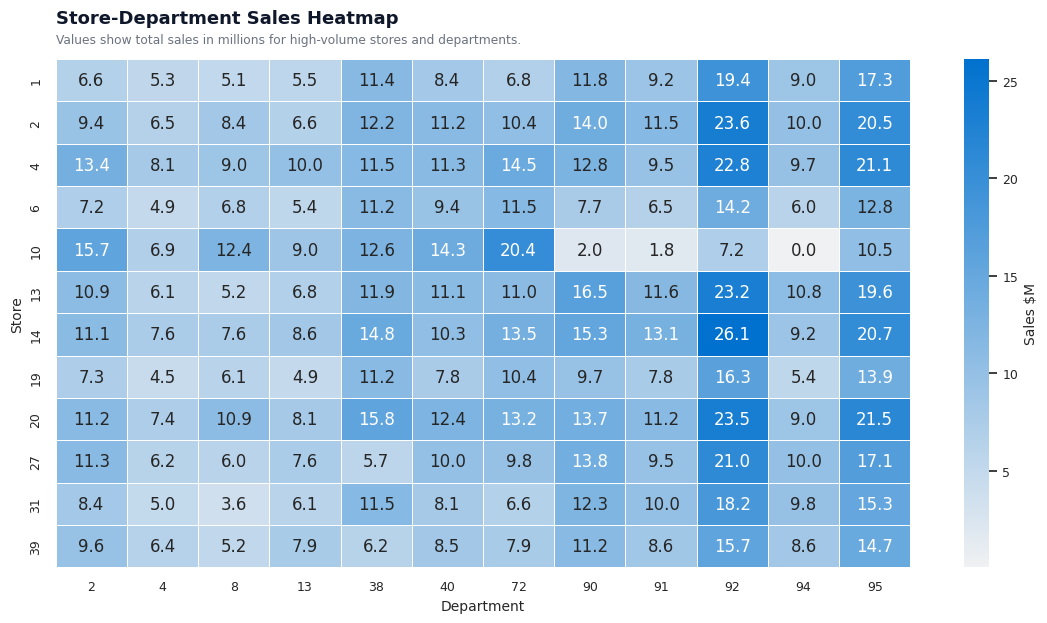

In [15]:
heat = (
    data.groupby(["Store", "Dept"], as_index=False)
    .agg(Total_Sales=("Weekly_Sales_Clean", "sum"))
)

top_stores = heat.groupby("Store")["Total_Sales"].sum().nlargest(12).index
top_depts = heat.groupby("Dept")["Total_Sales"].sum().nlargest(12).index

heat_matrix = (
    heat[heat["Store"].isin(top_stores) & heat["Dept"].isin(top_depts)]
    .pivot(index="Store", columns="Dept", values="Total_Sales")
    .fillna(0) / 1_000_000
)

fig, ax = plt.subplots(figsize=(11.5, 6.4))
sns.heatmap(
    heat_matrix,
    cmap=sns.light_palette(THEME["blue"], as_cmap=True),
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Sales $M"},
    ax=ax
)
set_chart_title(ax, "Store-Department Sales Heatmap", "Values show total sales in millions for high-volume stores and departments.")
ax.set_xlabel("Department")
ax.set_ylabel("Store")
plt.tight_layout()
plt.show()

The heatmap identifies high-value Store-Department combinations. These pairs are important for both forecast accuracy and stock planning priority.

# 6. Time Series Analysis

This section decomposes total weekly sales and a selected high-volume Store-Department series into observed behavior, trend, seasonality, and residuals. Residuals are displayed as points to make unexplained deviations easier to inspect.

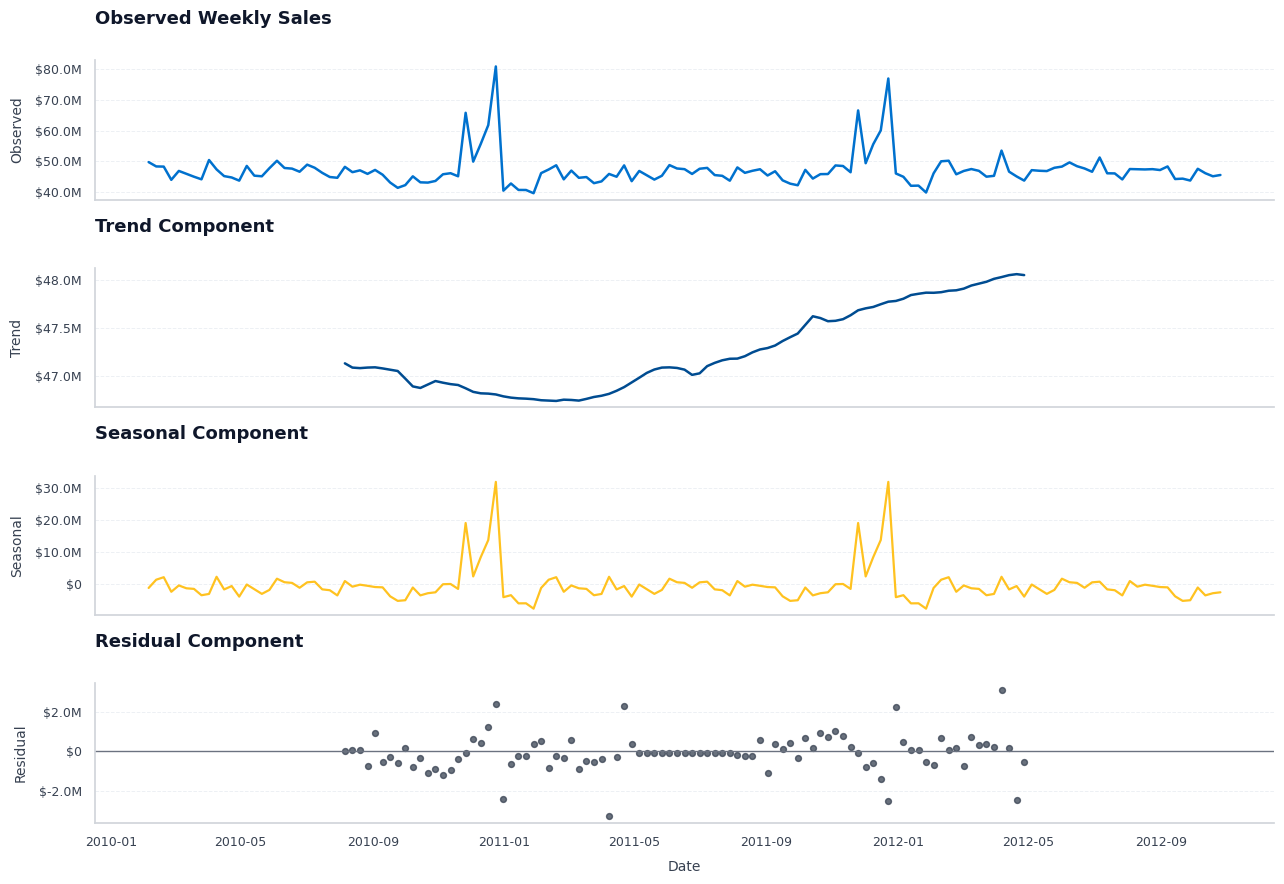

In [16]:
weekly_series = weekly_sales.set_index("Date")["Weekly_Sales"].asfreq("W-FRI")
weekly_series = weekly_series.interpolate()

decomp = seasonal_decompose(weekly_series, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

axes[0].plot(decomp.observed.index, decomp.observed, color=THEME["blue"], linewidth=1.8)
set_chart_title(axes[0], "Observed Weekly Sales")
clean_axis(axes[0], ylabel="Observed")

axes[1].plot(decomp.trend.index, decomp.trend, color=THEME["blue_dark"], linewidth=1.8)
set_chart_title(axes[1], "Trend Component")
clean_axis(axes[1], ylabel="Trend")

axes[2].plot(decomp.seasonal.index, decomp.seasonal, color=THEME["yellow"], linewidth=1.6)
set_chart_title(axes[2], "Seasonal Component")
clean_axis(axes[2], ylabel="Seasonal")

axes[3].scatter(decomp.resid.index, decomp.resid, color=THEME["gray_dark"], s=18, alpha=0.75)
axes[3].axhline(0, color=THEME["gray"], linewidth=1)
set_chart_title(axes[3], "Residual Component")
clean_axis(axes[3], xlabel="Date", ylabel="Residual")

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))

plt.tight_layout()
plt.show()

The decomposition separates stable structure from unexplained variation. Residual spikes represent demand behavior not fully explained by trend and seasonality, which is where markdown, holiday, or local store effects may matter.

In [17]:
selected_pair = (
    data.groupby(["Store", "Dept"], as_index=False)
    .agg(Total_Sales=("Weekly_Sales_Clean", "sum"))
    .sort_values("Total_Sales", ascending=False)
    .iloc[0]
)

SELECTED_STORE = int(selected_pair["Store"])
SELECTED_DEPT = int(selected_pair["Dept"])

selected_series = data[(data["Store"] == SELECTED_STORE) & (data["Dept"] == SELECTED_DEPT)].copy()
selected_series = selected_series.sort_values("Date")

kpi_cards([
    {"title": "Selected Store", "value": SELECTED_STORE, "note": "Highest-volume series", "accent": THEME["blue"]},
    {"title": "Selected Dept", "value": SELECTED_DEPT, "note": "Highest-volume series", "accent": THEME["yellow"]},
    {"title": "Total Series Sales", "value": money_fmt(selected_series["Weekly_Sales_Clean"].sum()), "note": "Clean sales", "accent": THEME["blue_dark"]},
    {"title": "Weekly Observations", "value": f"{len(selected_series):,}", "note": "Historical points", "accent": THEME["gray_dark"]}
], columns=4)

A high-volume Store-Department pair is selected for interpretable time-series benchmarks. This selected series does not replace full-dataset modeling; it provides a focused diagnostic view.

# 7. Feature Engineering

Feature engineering creates the predictive signals used by baseline, machine learning, segment-specific, and quantile models. The main feature groups are calendar, holiday, markdown, lag, rolling, and historical Store-Department statistics.

In [18]:
def add_core_features(df):
    out = df.copy()
    out["Year"] = out["Date"].dt.year
    out["Month"] = out["Date"].dt.month
    out["Week"] = out["Date"].dt.isocalendar().week.astype(int)
    out["Quarter"] = out["Date"].dt.quarter
    out["Day"] = out["Date"].dt.day
    out["IsMonthEnd"] = out["Date"].dt.is_month_end.astype(int)
    out["IsQ4"] = (out["Quarter"] == 4).astype(int)
    out["IsYearEndSeason"] = out["Month"].isin([11, 12]).astype(int)
    out["IsHolidayInt"] = out["IsHoliday"].astype(int)
    out["Holiday_Weight"] = np.where(out["IsHoliday"], 5, 1)

    for col in markdown_cols:
        out[col] = out[col].fillna(0)

    out["Total_MarkDown"] = out[markdown_cols].sum(axis=1)
    out["Has_MarkDown"] = (out["Total_MarkDown"] > 0).astype(int)
    out["Avg_MarkDown"] = out[markdown_cols].mean(axis=1)
    out["Max_MarkDown"] = out[markdown_cols].max(axis=1)
    out["Markdown_Count"] = (out[markdown_cols] > 0).sum(axis=1)
    out["Holiday_MarkDown_Interaction"] = out["IsHolidayInt"] * out["Has_MarkDown"]
    out["Holiday_MarkDown_Amount"] = out["Holiday_Weight"] * out["Total_MarkDown"]
    out["Type_Code"] = out["Type"].map({"A": 3, "B": 2, "C": 1}).fillna(0).astype(int)
    out["Store_Size_Log"] = np.log1p(out["Size"])
    return out

def add_lag_rolling_features(df):
    out = df.sort_values(["Store", "Dept", "Date"]).copy()
    group_cols = ["Store", "Dept"]
    target = "Weekly_Sales_Clean"

    if target in out.columns:
        for lag in [1, 2, 4, 8, 12, 26, 52]:
            out[f"lag_{lag}"] = out.groupby(group_cols)[target].shift(lag)

        for window in [4, 8, 12, 26]:
            out[f"rolling_mean_{window}"] = out.groupby(group_cols)[target].transform(
                lambda x: x.shift(1).rolling(window, min_periods=1).mean()
            )

        for window in [4, 12, 26]:
            out[f"rolling_std_{window}"] = out.groupby(group_cols)[target].transform(
                lambda x: x.shift(1).rolling(window, min_periods=2).std()
            )

        rolling_mean = out.groupby(group_cols)[target].transform(
            lambda x: x.shift(1).rolling(12, min_periods=4).mean()
        )
        rolling_std = out.groupby(group_cols)[target].transform(
            lambda x: x.shift(1).rolling(12, min_periods=4).std()
        )
        out["lagged_sales_zscore"] = (out["lag_1"] - rolling_mean) / rolling_std.replace(0, np.nan)
        out["Lagged_Outlier_Flag"] = (out["lagged_sales_zscore"].abs() > 3).astype(int)

    for col in ["Total_MarkDown", "Fuel_Price", "CPI", "Unemployment"]:
        if col in out.columns:
            for lag in [1, 2]:
                out[f"{col}_lag_{lag}"] = out.groupby(group_cols)[col].shift(lag)

    return out

data_fe = add_core_features(data)
data_fe = add_lag_rolling_features(data_fe)

store_econ = data_fe.groupby("Store", as_index=False).agg(
    Store_Fuel_Avg=("Fuel_Price", "mean"),
    Store_CPI_Avg=("CPI", "mean")
)

data_fe = data_fe.merge(store_econ, on="Store", how="left")
data_fe["Fuel_Relative_To_Store"] = data_fe["Fuel_Price"] / data_fe["Store_Fuel_Avg"]
data_fe["CPI_Relative_To_Store"] = data_fe["CPI"] / data_fe["Store_CPI_Avg"]

feature_preview_cols = [
    "Store", "Dept", "Date", "Weekly_Sales_Clean", "Week", "IsHoliday",
    "Total_MarkDown", "Total_MarkDown_lag_1", "Fuel_Price_lag_1", "CPI_lag_1",
    "lag_1", "lag_52", "rolling_mean_4", "rolling_std_12", "Lagged_Outlier_Flag"
]

pretty_table(
    data_fe[feature_preview_cols].dropna().head(12),
    "Feature Engineering Preview",
    12
)

,Store,Dept,Date,Weekly_Sales_Clean,Week,IsHoliday,Total_MarkDown,Total_MarkDown_lag_1,Fuel_Price_lag_1,CPI_lag_1,lag_1,lag_52,rolling_mean_4,rolling_std_12,Lagged_Outlier_Flag
52,1,1,2011-02-04 00:00:00,"21,665.76",5,False,0.00,0.00,3.01,212.20,"18,461.18","24,924.50","17,286.65","12,701.86",0
53,1,1,2011-02-11 00:00:00,"37,887.17",6,True,0.00,0.00,2.99,212.57,"21,665.76","46,039.49","18,707.03","12,632.47",0
54,1,1,2011-02-18 00:00:00,"46,845.87",7,False,0.00,0.00,3.02,212.94,"37,887.17","41,595.55","23,838.89","12,982.80",0
55,1,1,2011-02-25 00:00:00,"19,363.83",8,False,0.00,0.00,3.04,213.25,"46,845.87","19,403.54","31,214.99","13,906.32",0
56,1,1,2011-03-04 00:00:00,"20,327.61",9,False,0.00,0.00,3.06,213.54,"19,363.83","21,827.90","31,440.66","14,071.41",0
57,1,1,2011-03-11 00:00:00,"21,280.40",10,False,0.00,0.00,3.29,213.82,"20,327.61","21,043.39","31,106.12","14,249.72",0
58,1,1,2011-03-18 00:00:00,"20,334.23",11,False,0.00,0.00,3.46,214.11,"21,280.40","22,136.64","26,954.43","13,290.59",0
59,1,1,2011-03-25 00:00:00,"20,881.10",12,False,0.00,0.00,3.49,214.36,"20,334.23","26,229.21","20,326.52","9,396.00",0
60,1,1,2011-04-01 00:00:00,"20,398.09",13,False,0.00,0.00,3.47,214.60,"20,881.10","57,258.43","20,705.83","9,343.71",0
61,1,1,2011-04-08 00:00:00,"23,873.79",14,False,0.00,0.00,3.52,214.84,"20,398.09","42,960.91","20,723.45","9,120.43",0


The feature set now includes delayed markdown signals, lagged economic variables, relative store-level economic indicators, strengthened holiday-markdown interaction, recent and seasonal sales history, volatility, and lagged outlier flags.

# 8. Validation Strategy and Metrics

The validation split is time-based. Older dates are used for training and the most recent historical period is used for validation. This better reflects the real forecasting problem and reduces the risk of data leakage.

In [19]:
unique_dates = np.array(sorted(data_fe["Date"].unique()))
valid_weeks = 26
valid_start = pd.Timestamp(unique_dates[-valid_weeks])

train_fe = data_fe[data_fe["Date"] < valid_start].copy()
valid_fe = data_fe[data_fe["Date"] >= valid_start].copy()

def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, np.nan, denom)
    return np.nanmean(np.abs(y_true - y_pred) / denom)

def build_historical_stats(frame, target="Weekly_Sales_Clean"):
    sd_stats = frame.groupby(["Store", "Dept"], as_index=False).agg(
        StoreDept_Avg_Sales=(target, "mean"),
        StoreDept_Sales_Std=(target, "std"),
        StoreDept_Total_Sales=(target, "sum")
    )
    sd_stats = sd_stats.sort_values("StoreDept_Total_Sales", ascending=False)
    sd_stats["Cum_Share"] = sd_stats["StoreDept_Total_Sales"].cumsum() / sd_stats["StoreDept_Total_Sales"].sum()
    sd_stats["ABC_Segment"] = pd.cut(
        sd_stats["Cum_Share"],
        bins=[0, 0.8, 0.95, 1.0],
        labels=["A", "B", "C"],
        include_lowest=True
    )
    store_avg = frame.groupby("Store", as_index=False).agg(Store_Avg_Sales=(target, "mean"))
    dept_avg = frame.groupby("Dept", as_index=False).agg(Dept_Avg_Sales=(target, "mean"))
    return sd_stats, store_avg, dept_avg

def add_historical_stats(frame, sd_stats, store_avg, dept_avg):
    out = frame.copy()
    drop_cols = [
        "StoreDept_Avg_Sales", "StoreDept_Sales_Std", "ABC_Segment",
        "Store_Avg_Sales", "Dept_Avg_Sales", "ABC_Code"
    ]
    out = out.drop(columns=[c for c in drop_cols if c in out.columns], errors="ignore")
    out = out.merge(
        sd_stats[["Store", "Dept", "StoreDept_Avg_Sales", "StoreDept_Sales_Std", "ABC_Segment"]],
        on=["Store", "Dept"],
        how="left"
    )
    out = out.merge(store_avg, on="Store", how="left")
    out = out.merge(dept_avg, on="Dept", how="left")
    out["ABC_Code"] = out["ABC_Segment"].map({"A": 3, "B": 2, "C": 1}).astype(float)
    return out

sd_stats, store_avg, dept_avg = build_historical_stats(train_fe)
train_fe = add_historical_stats(train_fe, sd_stats, store_avg, dept_avg)
valid_fe = add_historical_stats(valid_fe, sd_stats, store_avg, dept_avg)

feature_cols = [
    "Store", "Dept", "Size", "Store_Size_Log", "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "Fuel_Relative_To_Store", "CPI_Relative_To_Store",
    "Year", "Month", "Week", "Quarter", "Day", "IsMonthEnd", "IsQ4", "IsYearEndSeason",
    "IsHolidayInt", "Holiday_Weight",
    "Total_MarkDown", "Has_MarkDown", "Avg_MarkDown", "Max_MarkDown", "Markdown_Count",
    "Holiday_MarkDown_Interaction", "Holiday_MarkDown_Amount", "Type_Code",
    "Total_MarkDown_lag_1", "Total_MarkDown_lag_2",
    "Fuel_Price_lag_1", "Fuel_Price_lag_2", "CPI_lag_1", "CPI_lag_2",
    "Unemployment_lag_1", "Unemployment_lag_2",
    "lag_1", "lag_2", "lag_4", "lag_8", "lag_12", "lag_26", "lag_52",
    "rolling_mean_4", "rolling_mean_8", "rolling_mean_12", "rolling_mean_26",
    "rolling_std_4", "rolling_std_12", "rolling_std_26",
    "lagged_sales_zscore", "Lagged_Outlier_Flag",
    "StoreDept_Avg_Sales", "StoreDept_Sales_Std", "Store_Avg_Sales", "Dept_Avg_Sales", "ABC_Code",
    "Negative_Sales_Flag"
]
feature_cols = [c for c in feature_cols if c in train_fe.columns]

model_train = train_fe.dropna(subset=["Weekly_Sales_Clean"]).copy()
model_valid = valid_fe.copy()

global_fill = model_train[feature_cols].median(numeric_only=True)

X_train = model_train[feature_cols].fillna(global_fill)
y_train = model_train["Weekly_Sales_Clean"]
X_valid = model_valid[feature_cols].fillna(global_fill)
y_valid = model_valid["Weekly_Sales_Clean"]

def evaluate_model(name, frame, pred_col):
    temp = frame.dropna(subset=[pred_col, "Weekly_Sales_Clean"]).copy()
    y_true = temp["Weekly_Sales_Clean"]
    y_pred = temp[pred_col].clip(lower=0)
    is_holiday = temp["IsHoliday"].astype(bool)
    holiday_mask = is_holiday
    nonholiday_mask = ~is_holiday
    return {
        "Model": name,
        "WMAE": wmae(y_true, y_pred, is_holiday),
        "Holiday_WMAE": wmae(y_true[holiday_mask], y_pred[holiday_mask], is_holiday[holiday_mask]) if holiday_mask.any() else np.nan,
        "NonHoliday_WMAE": wmae(y_true[nonholiday_mask], y_pred[nonholiday_mask], is_holiday[nonholiday_mask]) if nonholiday_mask.any() else np.nan,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": wape(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred)
    }

split_summary = pd.DataFrame({
    "Set": ["Train", "Validation"],
    "Start Date": [model_train["Date"].min(), model_valid["Date"].min()],
    "End Date": [model_train["Date"].max(), model_valid["Date"].max()],
    "Rows": [len(model_train), len(model_valid)],
    "Holiday Rows": [int(model_train["IsHoliday"].sum()), int(model_valid["IsHoliday"].sum())]
})

pretty_table(split_summary, "Time-Based Validation Split", 10)

,Set,Start Date,End Date,Rows,Holiday Rows
0,Train,2010-02-05 00:00:00,2012-04-27 00:00:00,"344,667","26,695"
1,Validation,2012-05-04 00:00:00,2012-10-26 00:00:00,"76,903","2,966"


The validation window now uses a longer recent period, and historical store-department statistics are computed from training data only. This improves realism and reduces data leakage risk.

# 9. Baseline Models

Baseline models establish the reference performance level. An advanced model should only be considered useful if it improves meaningfully over these simple, transparent rules.

In [20]:
valid_base = valid_fe.copy()
valid_base["pred_lag1"] = valid_base["lag_1"]
valid_base["pred_ma4"] = valid_base["rolling_mean_4"]
valid_base["pred_ma8"] = valid_base["rolling_mean_8"]
valid_base["pred_ma12"] = valid_base["rolling_mean_12"]
valid_base["pred_seasonal52"] = valid_base["lag_52"]

baseline_rows = []
for name, col in [
    ("Naive Lag-1", "pred_lag1"),
    ("Moving Average 4", "pred_ma4"),
    ("Moving Average 8", "pred_ma8"),
    ("Moving Average 12", "pred_ma12"),
    ("Seasonal Naive 52", "pred_seasonal52")
]:
    baseline_rows.append(evaluate_model(name, valid_base, col))

baseline_eval_df = pd.DataFrame(baseline_rows).sort_values("WMAE").reset_index(drop=True)

In [21]:
pretty_table(baseline_eval_df, "Baseline Model Leaderboard", 10)

,Model,WMAE,Holiday_WMAE,NonHoliday_WMAE,MAE,RMSE,WAPE,SMAPE
0,Moving Average 4,"1,614.02","1,954.21","1,545.79","1,561.54","3,434.63",0.10,0.20
1,Naive Lag-1,"1,622.62","2,113.27","1,524.22","1,546.93","3,442.35",0.10,0.19
2,Seasonal Naive 52,"1,780.44","1,845.18","1,767.47","1,770.46","3,633.29",0.11,0.23
3,Moving Average 8,"1,808.58","1,944.80","1,781.26","1,787.56","3,899.46",0.11,0.22
4,Moving Average 12,"1,965.68","2,072.84","1,944.19","1,949.15","4,202.64",0.12,0.23


The baseline leaderboard defines the reference performance level. Advanced models should only be considered useful if they reduce WMAE against these simple historical rules.

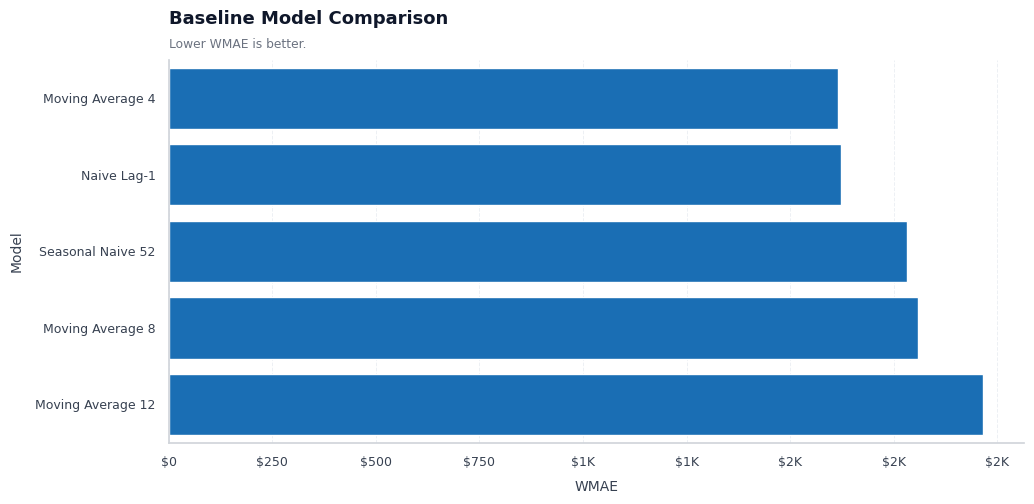

In [22]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.barplot(data=baseline_eval_df, x="WMAE", y="Model", color=THEME["blue"], ax=ax)
ax.xaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Baseline Model Comparison", "Lower WMAE is better.")
clean_axis(ax, xlabel="WMAE", ylabel="Model", xgrid=True)
plt.tight_layout()
plt.show()

The baseline comparison shows how much predictive power already exists in recent and seasonal sales history; advanced models should only be considered valuable if they reduce WMAE beyond these transparent reference rules.

# 10. Prophet Benchmark

Prophet is used as an interpretable benchmark for one high-volume Store-Department series, while the full-scale forecasting task remains with the tabular ML model because training separate Prophet models for thousands of series would increase runtime and maintenance cost.

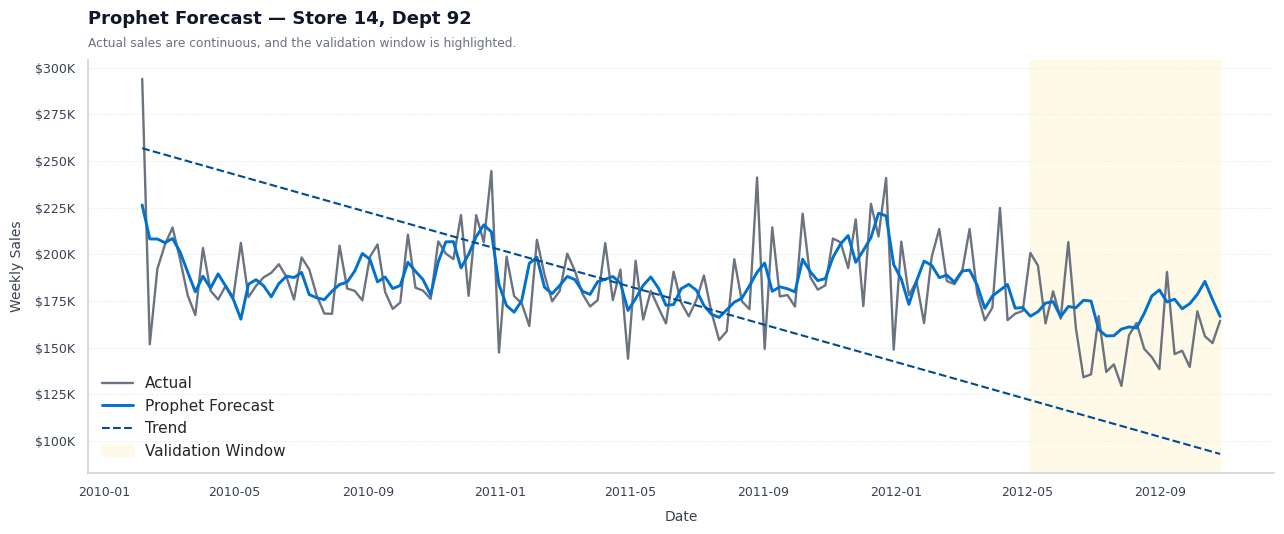

In [23]:
try:
    from prophet import Prophet
    prophet_available = True
except Exception:
    prophet_available = False

prophet_scores = []

if prophet_available:
    prop_df = selected_series[["Date", "Weekly_Sales_Clean", "IsHoliday", "Total_MarkDown", "Temperature", "Fuel_Price", "CPI", "Unemployment"]].copy()
    prop_df = prop_df.rename(columns={"Date": "ds", "Weekly_Sales_Clean": "y"})
    prop_df["holiday_flag"] = prop_df["IsHoliday"].astype(int)
    prop_df["Total_MarkDown"] = prop_df["Total_MarkDown"].fillna(0)
    for c in ["Temperature", "Fuel_Price", "CPI", "Unemployment"]:
        prop_df[c] = prop_df[c].ffill().bfill()

    prop_train = prop_df[prop_df["ds"] < valid_start].copy()
    prop_valid = prop_df[prop_df["ds"] >= valid_start].copy()

    holidays = prop_train.loc[prop_train["holiday_flag"] == 1, ["ds"]].copy()
    holidays["holiday"] = "holiday_week"

    prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, holidays=holidays)
    for reg in ["holiday_flag", "Total_MarkDown", "Temperature", "Fuel_Price", "CPI", "Unemployment"]:
        prophet_model.add_regressor(reg)

    reg_cols = ["ds", "y", "holiday_flag", "Total_MarkDown", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
    with silent_output():
        prophet_model.fit(prop_train[reg_cols])

    future = prop_df[["ds", "holiday_flag", "Total_MarkDown", "Temperature", "Fuel_Price", "CPI", "Unemployment"]]
    forecast = prophet_model.predict(future)

    prop_eval = prop_df.merge(forecast[["ds", "yhat", "trend"]], on="ds", how="left")
    prop_valid_eval = prop_eval[prop_eval["ds"] >= valid_start].copy()

    prophet_scores.append({
        "Model": f"Prophet Store {SELECTED_STORE} Dept {SELECTED_DEPT}",
        "WMAE": wmae(prop_valid_eval["y"], prop_valid_eval["yhat"], prop_valid_eval["IsHoliday"]),
        "MAE": mean_absolute_error(prop_valid_eval["y"], prop_valid_eval["yhat"]),
        "RMSE": np.sqrt(mean_squared_error(prop_valid_eval["y"], prop_valid_eval["yhat"]))
    })

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(prop_eval["ds"], prop_eval["y"], color=THEME["gray"], linewidth=1.7, label="Actual")
    ax.plot(prop_eval["ds"], prop_eval["yhat"], color=THEME["blue"], linewidth=2.1, label="Prophet Forecast")
    ax.plot(prop_eval["ds"], prop_eval["trend"], color=THEME["blue_dark"], linestyle="--", linewidth=1.5, label="Trend")
    ax.axvspan(valid_start, prop_eval["ds"].max(), color=THEME["yellow_soft"], alpha=0.4, label="Validation Window")
    ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
    set_chart_title(ax, f"Prophet Forecast — Store {SELECTED_STORE}, Dept {SELECTED_DEPT}", "Actual sales are continuous, and the validation window is highlighted.")
    clean_axis(ax, xlabel="Date", ylabel="Weekly Sales")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

else:
    prophet_scores = []
    output_note("Prophet is not available in this environment. This benchmark can be enabled by installing prophet.")

Prophet is used as an interpretable benchmark for one selected high-volume Store-Department series. It helps explain trend and seasonality, but it is not scaled to every series because thousands of separate Prophet models would increase runtime and maintenance cost.

# 11. SARIMA Benchmark

SARIMA is used as a classical benchmark for one selected Store-Department series, providing a traditional seasonal time-series comparison against Prophet and machine learning while keeping the workflow scalable and readable.

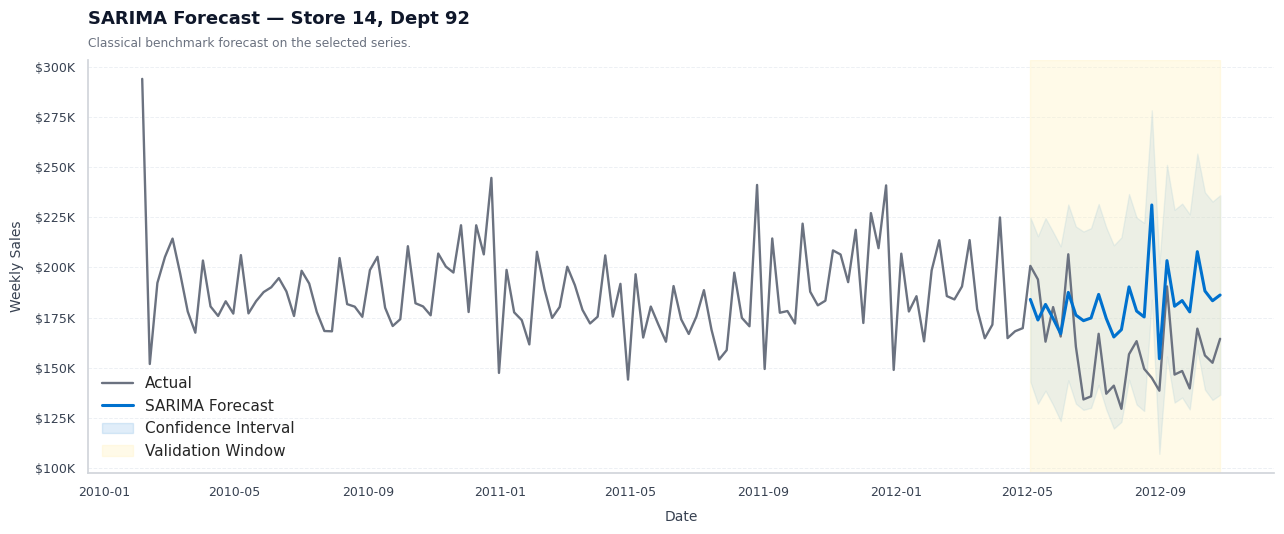

In [24]:
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    sarima_available = True
except Exception:
    sarima_available = False

sarima_scores = []

if sarima_available:
    sarima_series = selected_series.set_index("Date")["Weekly_Sales_Clean"].asfreq("W-FRI").interpolate()
    sarima_train = sarima_series[sarima_series.index < valid_start]
    sarima_valid = sarima_series[sarima_series.index >= valid_start]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with silent_output():
                sarima_model = SARIMAX(
                    sarima_train,
                    order=(1, 1, 1),
                    seasonal_order=(1, 0, 1, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)

        sarima_forecast = sarima_model.get_forecast(steps=len(sarima_valid))
        sarima_pred = sarima_forecast.predicted_mean.clip(lower=0)
        sarima_ci = sarima_forecast.conf_int()

        sarima_eval_frame = pd.DataFrame({
            "Date": sarima_valid.index,
            "Weekly_Sales_Clean": sarima_valid.values,
            "pred_sarima": sarima_pred.values,
            "IsHoliday": selected_series.set_index("Date").reindex(sarima_valid.index)["IsHoliday"].fillna(False).values
        })

        sarima_scores.append(evaluate_model(f"SARIMA Store {SELECTED_STORE} Dept {SELECTED_DEPT}", sarima_eval_frame, "pred_sarima"))

        fig, ax = plt.subplots(figsize=(13, 5.5))
        ax.plot(sarima_series.index, sarima_series.values, color=THEME["gray"], linewidth=1.7, label="Actual")
        ax.plot(sarima_pred.index, sarima_pred.values, color=THEME["blue"], linewidth=2.2, label="SARIMA Forecast")
        ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color=THEME["blue"], alpha=0.12, label="Confidence Interval")
        ax.axvspan(valid_start, sarima_series.index.max(), color=THEME["yellow_soft"], alpha=0.4, label="Validation Window")
        ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
        set_chart_title(ax, f"SARIMA Forecast — Store {SELECTED_STORE}, Dept {SELECTED_DEPT}", "Classical benchmark forecast on the selected series.")
        clean_axis(ax, xlabel="Date", ylabel="Weekly Sales")
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        output_note(f"SARIMA could not be fitted for the selected series: {e}")
else:
    output_note("SARIMA is not available in this environment.")

SARIMA provides a classical statistical benchmark for the selected Store-Department series. It is useful for comparison, while the full-scale forecasting responsibility remains with the tabular machine learning model.

# 12. Main Machine Learning Forecasting Model

The main model uses the full Store-Department dataset with engineered tabular forecasting features. LightGBM is preferred when available because it is efficient for large structured data. A scikit-learn fallback is used when LightGBM is not installed.

In [25]:
try:
    from lightgbm import LGBMRegressor
    import lightgbm as lgb
    lgbm_available = True
except Exception:
    lgbm_available = False

def make_lgbm(params=None):
    base_params = {
        "n_estimators": 1200,
        "learning_rate": 0.045,
        "num_leaves": 63,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_samples": 50,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }
    if params:
        base_params.update(params)
    return LGBMRegressor(**base_params)

def fit_model(model, X_tr, y_tr, X_va=None, y_va=None, sample_weight=None):
    if lgbm_available and isinstance(model, LGBMRegressor) and X_va is not None:
        try:
            model.fit(
                X_tr,
                y_tr,
                sample_weight=sample_weight,
                eval_set=[(X_va, y_va)],
                eval_metric="l1",
                callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(0)]
            )
        except Exception:
            model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        try:
            model.fit(X_tr, y_tr, sample_weight=sample_weight)
        except TypeError:
            model.fit(X_tr, y_tr)
    return model

if lgbm_available:
    main_model = make_lgbm()
else:
    main_model = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.06,
        max_leaf_nodes=63,
        random_state=42
    )

main_model = fit_model(
    main_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    sample_weight=model_train["Holiday_Weight"]
)

model_valid["pred_main"] = np.maximum(main_model.predict(X_valid), 0)
main_eval = evaluate_model("Main ML Model", model_valid, "pred_main")

In [26]:
pretty_table(pd.DataFrame([main_eval]), "Main Model Validation Metrics", 5)

,Model,WMAE,Holiday_WMAE,NonHoliday_WMAE,MAE,RMSE,WAPE,SMAPE
0,Main ML Model,"1,377.26","1,831.36","1,286.17","1,307.20","2,790.05",0.08,0.25


The main model is evaluated on the time-based validation window. This table is the first full-data benchmark after baseline models.

# 12.1 Rolling Time-Series Validation

A single validation window can hide instability. Rolling validation evaluates the model across several time-ordered windows and checks whether performance remains reliable across different market periods. This is especially important for Walmart because year-end events, holiday weeks, and promotional cycles can shift forecast difficulty over time.

In [27]:
def rolling_time_splits(frame, n_folds=4, validation_weeks=12):
    dates = np.array(sorted(frame["Date"].unique()))
    folds = []
    min_train_weeks = 70
    step = max((len(dates) - min_train_weeks - validation_weeks) // max(n_folds, 1), 1)
    starts = list(range(min_train_weeks, len(dates) - validation_weeks + 1, step))[-n_folds:]
    for start in starts:
        train_end = dates[start]
        valid_end = dates[start + validation_weeks - 1]
        train_idx = frame["Date"] < train_end
        valid_idx = (frame["Date"] >= train_end) & (frame["Date"] <= valid_end)
        if train_idx.sum() > 0 and valid_idx.sum() > 0:
            folds.append((train_idx, valid_idx, pd.Timestamp(train_end), pd.Timestamp(valid_end)))
    return folds

cv_rows = []
folds = rolling_time_splits(data_fe, n_folds=4, validation_weeks=12)

for fold_id, (tr_idx, va_idx, start, end) in enumerate(folds, start=1):
    fold_train = data_fe[tr_idx].copy()
    fold_valid = data_fe[va_idx].copy()

    fold_sd, fold_store, fold_dept = build_historical_stats(fold_train)
    fold_train = add_historical_stats(fold_train, fold_sd, fold_store, fold_dept)
    fold_valid = add_historical_stats(fold_valid, fold_sd, fold_store, fold_dept)

    fold_features = [c for c in feature_cols if c in fold_train.columns]
    fold_fill = fold_train[fold_features].median(numeric_only=True)

    X_tr = fold_train[fold_features].fillna(fold_fill)
    y_tr = fold_train["Weekly_Sales_Clean"]
    X_va = fold_valid[fold_features].fillna(fold_fill)
    y_va = fold_valid["Weekly_Sales_Clean"]

    if lgbm_available:
        fold_model = make_lgbm({"n_estimators": 650, "learning_rate": 0.05})
    else:
        fold_model = HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.06,
            max_leaf_nodes=63,
            random_state=42
        )

    fold_model = fit_model(
        fold_model,
        X_tr,
        y_tr,
        X_va,
        y_va,
        sample_weight=fold_train["Holiday_Weight"] if "Holiday_Weight" in fold_train.columns else None
    )

    fold_pred = np.maximum(fold_model.predict(X_va), 0)

    cv_rows.append({
        "Fold": fold_id,
        "Validation_Start": start,
        "Validation_End": end,
        "Rows": len(fold_valid),
        "WMAE": wmae(y_va, fold_pred, fold_valid["IsHoliday"]),
        "WAPE": wape(y_va, fold_pred)
    })

cv_df = pd.DataFrame(cv_rows)

In [28]:
pretty_table(cv_df, "Rolling Time-Series Validation", 10)

,Fold,Validation_Start,Validation_End,Rows,WMAE,WAPE
0,1,2011-09-23 00:00:00,2011-12-09 00:00:00,"35,633","2,379.97",0.11
1,2,2012-01-06 00:00:00,2012-03-23 00:00:00,"35,685","1,604.56",0.10
2,3,2012-04-20 00:00:00,2012-07-06 00:00:00,"35,465","1,410.48",0.09
3,4,2012-08-03 00:00:00,2012-10-19 00:00:00,"35,571","1,336.79",0.08


Rolling validation evaluates model stability across multiple historical windows, showing whether performance improves with more recent training data and whether holiday-heavy periods require stronger features or wider inventory buffers.

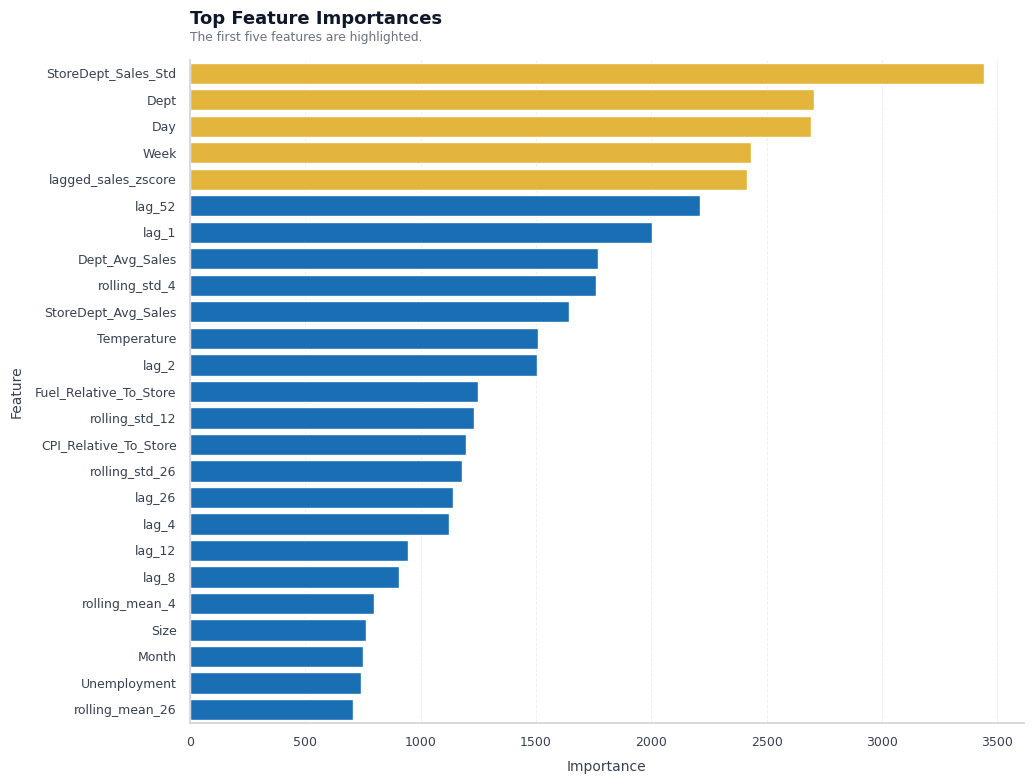

In [29]:
if hasattr(main_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": main_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(10.5, 8))
    colors = [THEME["yellow"] if i < 5 else THEME["blue"] for i in range(len(importance_df))]
    sns.barplot(data=importance_df, y="Feature", x="Importance", palette=colors, ax=ax)
    set_chart_title(ax, "Top Feature Importances", "The first five features are highlighted.")
    clean_axis(ax, xlabel="Importance", ylabel="Feature", xgrid=True)
    plt.tight_layout()
    plt.show()
else:
    importance_df = pd.DataFrame({"Feature": feature_cols, "Importance": np.nan})

Feature importance shows which demand signals the model relies on most. Lag, rolling, calendar, store, department, and markdown features should generally appear among the strongest predictors.

# 13. WMAE-Targeted Hyperparameter Tuning

The tuning search is aligned with WMAE, the business-critical evaluation metric. The parameter ranges are intentionally moderate: `n_estimators` controls model capacity, `learning_rate` controls how gradually the model learns, `num_leaves` controls tree complexity, and `min_child_samples` limits overfitting on sparse store-department patterns. This keeps the search effective without making the notebook unnecessarily slow.

In [30]:
tuned_model = None
tuned_eval = None
best_params = None

if lgbm_available:
    param_grid = {
        "n_estimators": [500, 800, 1200],
        "learning_rate": [0.03, 0.045, 0.06],
        "num_leaves": [31, 63, 95],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
        "min_child_samples": [20, 50, 80]
    }

    sampled_params = list(ParameterSampler(param_grid, n_iter=10, random_state=42))
    tuning_rows = []

    for trial_id, params in enumerate(sampled_params, start=1):
        clean_params = params.copy()
        clean_params["n_estimators"] = int(clean_params["n_estimators"])
        clean_params["num_leaves"] = int(clean_params["num_leaves"])
        clean_params["min_child_samples"] = int(clean_params["min_child_samples"])

        tune_model = make_lgbm(clean_params)
        tune_model = fit_model(
            tune_model,
            X_train,
            y_train,
            X_valid,
            y_valid,
            sample_weight=model_train["Holiday_Weight"]
        )

        pred = np.maximum(tune_model.predict(X_valid), 0)
        score = wmae(y_valid, pred, model_valid["IsHoliday"])

        tuning_rows.append({
            "Trial": trial_id,
            "WMAE": score,
            **clean_params
        })

    tuning_df = pd.DataFrame(tuning_rows).sort_values("WMAE").reset_index(drop=True)

    best_params = tuning_df.loc[0, [
        "n_estimators", "learning_rate", "num_leaves",
        "subsample", "colsample_bytree", "min_child_samples"
    ]].to_dict()

    best_params["n_estimators"] = int(best_params["n_estimators"])
    best_params["num_leaves"] = int(best_params["num_leaves"])
    best_params["min_child_samples"] = int(best_params["min_child_samples"])

    tuned_model = make_lgbm(best_params)
    tuned_model = fit_model(
        tuned_model,
        X_train,
        y_train,
        X_valid,
        y_valid,
        sample_weight=model_train["Holiday_Weight"]
    )

    model_valid["pred_tuned"] = np.maximum(tuned_model.predict(X_valid), 0)
    tuned_eval = evaluate_model("WMAE-Tuned LightGBM", model_valid, "pred_tuned")
else:
    tuning_df = pd.DataFrame({"Status": ["LightGBM is unavailable. Tuning was skipped."]})

In [31]:
pretty_table(tuning_df, "WMAE Tuning Results", 12)

,Trial,WMAE,subsample,num_leaves,n_estimators,min_child_samples,learning_rate,colsample_bytree
0,9,"1,361.69",0.90,95,"1,200",50,0.04,0.80
1,2,"1,367.65",0.90,63,800,80,0.04,0.80
2,4,"1,389.29",0.90,63,500,50,0.04,0.90
3,10,"1,392.20",0.80,31,"1,200",20,0.04,0.90
4,3,"1,392.93",1.00,63,500,80,0.03,0.90
5,6,"1,399.39",1.00,63,"1,200",20,0.03,0.90
6,8,"1,408.73",0.80,31,500,20,0.04,0.80
7,1,"1,424.65",0.80,31,800,80,0.06,0.90
8,7,"1,431.77",0.80,31,"1,200",80,0.03,0.80
9,5,"1,433.03",1.00,31,500,50,0.03,1.00


The tuning table ranks candidate LightGBM parameter sets by WMAE, aligning model selection with the business-weighted metric.

Hyperparameter candidates are ranked directly by WMAE. The best candidate becomes the tuned model and is carried forward into later comparison layers.

# 14. Store-Department Segment Model Strategy

Store-department pairs are segmented by historical sales contribution. A-segment series carry high sales volume and justify more flexible models. B-segment series need balanced complexity. C-segment series are long-tail and often benefit from simpler, more regularized models. This section trains segment-specific models and compares their performance against the global model.

In [32]:
segment_valid = model_valid.copy()
segment_valid["pred_segment"] = np.nan
segment_models = {}
segment_rows = []

segment_param_grid = {
    "A": {
        "n_estimators": [700, 1000, 1300],
        "learning_rate": [0.035, 0.045, 0.055],
        "num_leaves": [63, 95, 127],
        "min_child_samples": [20, 40, 60]
    },
    "B": {
        "n_estimators": [500, 800, 1000],
        "learning_rate": [0.04, 0.055, 0.07],
        "num_leaves": [31, 63, 95],
        "min_child_samples": [40, 70, 100]
    },
    "C": {
        "n_estimators": [300, 500, 700],
        "learning_rate": [0.05, 0.07, 0.09],
        "num_leaves": [15, 31, 63],
        "min_child_samples": [60, 100, 140]
    }
}

global_model_col = "pred_tuned" if "pred_tuned" in model_valid.columns else "pred_main"

for segment in ["A", "B", "C"]:
    seg_train = model_train[model_train["ABC_Segment"].astype(str) == segment].copy()
    seg_valid_idx = segment_valid[segment_valid["ABC_Segment"].astype(str) == segment].index

    if len(seg_train) <= 1000 or len(seg_valid_idx) == 0:
        continue

    X_seg = seg_train[feature_cols].fillna(global_fill)
    y_seg = seg_train["Weekly_Sales_Clean"]
    X_seg_valid = segment_valid.loc[seg_valid_idx, feature_cols].fillna(global_fill)
    y_seg_valid = segment_valid.loc[seg_valid_idx, "Weekly_Sales_Clean"]

    if lgbm_available:
        candidate_params = list(ParameterSampler(
            segment_param_grid[segment],
            n_iter=5,
            random_state=42
        ))

        best_score = np.inf
        best_segment_model = None
        best_segment_params = None

        for params in candidate_params:
            params = params.copy()
            params["n_estimators"] = int(params["n_estimators"])
            params["num_leaves"] = int(params["num_leaves"])
            params["min_child_samples"] = int(params["min_child_samples"])

            segment_model = make_lgbm(params)
            segment_model = fit_model(
                segment_model,
                X_seg,
                y_seg,
                X_seg_valid,
                y_seg_valid,
                sample_weight=seg_train["Holiday_Weight"]
            )

            seg_pred = np.maximum(segment_model.predict(X_seg_valid), 0)
            seg_score = wmae(
                y_seg_valid,
                seg_pred,
                segment_valid.loc[seg_valid_idx, "IsHoliday"]
            )

            if seg_score < best_score:
                best_score = seg_score
                best_segment_model = segment_model
                best_segment_params = params
    else:
        best_segment_model = HistGradientBoostingRegressor(
            max_iter=350,
            learning_rate=0.06,
            max_leaf_nodes=63,
            random_state=42
        )
        best_segment_model.fit(X_seg, y_seg)
        best_segment_params = {"fallback": "HistGradientBoostingRegressor"}

    segment_models[segment] = best_segment_model
    segment_valid.loc[seg_valid_idx, "pred_segment"] = np.maximum(
        best_segment_model.predict(X_seg_valid),
        0
    )

    segment_rows.append({
        "Segment": segment,
        "Train_Rows": len(seg_train),
        "Valid_Rows": len(seg_valid_idx),
        "Segment_WMAE": wmae(
            segment_valid.loc[seg_valid_idx, "Weekly_Sales_Clean"],
            segment_valid.loc[seg_valid_idx, "pred_segment"],
            segment_valid.loc[seg_valid_idx, "IsHoliday"]
        ),
        "Global_WMAE_SameRows": wmae(
            segment_valid.loc[seg_valid_idx, "Weekly_Sales_Clean"],
            model_valid.loc[seg_valid_idx, global_model_col],
            segment_valid.loc[seg_valid_idx, "IsHoliday"]
        ),
        "Best_Params": str(best_segment_params)
    })

segment_eval = pd.DataFrame(segment_rows)

if len(segment_eval):
    segment_eval["Delta_vs_Global"] = segment_eval["Segment_WMAE"] - segment_eval["Global_WMAE_SameRows"]

model_valid["pred_segment"] = segment_valid["pred_segment"]

In [33]:
pretty_table(segment_eval, "Segment-Specific Model Evaluation", 10)

,Segment,Train_Rows,Valid_Rows,Segment_WMAE,Global_WMAE_SameRows,Best_Params,Delta_vs_Global
0,A,"117,751","26,165","2,691.68","2,731.05","{'num_leaves': 95, 'n_estimators': 1000, 'min_child_samples': 20, 'learning_rate': 0.045}",-39.37
1,B,"87,652","19,405","1,030.52","1,109.35","{'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 40, 'learning_rate': 0.055}",-78.84
2,C,"139,244","31,275",336.08,368.98,"{'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 60, 'learning_rate': 0.07}",-32.89


Segment-specific results show whether A/B/C store-department groups benefit from separate parameter search; a negative delta versus the global model indicates that the segment model improves WMAE on the same validation rows.

# 14.1 Ensemble and Error Correction

The ensemble tests whether global, segment-specific, and baseline forecasts contain complementary signals. The error-correction model is evaluated separately because residuals are not always learnable: if remaining errors are mostly random, a second model can overfit noise instead of improving WMAE.

In [34]:
baseline_col_map = {
    "Naive Lag-1": "pred_lag1",
    "Moving Average 4": "pred_ma4",
    "Moving Average 8": "pred_ma8",
    "Moving Average 12": "pred_ma12",
    "Seasonal Naive 52": "pred_seasonal52"
}

if "baseline_eval_df" in globals() and len(baseline_eval_df) > 0:
    best_baseline_name = baseline_eval_df.sort_values("WMAE").iloc[0]["Model"]
    best_baseline_col = baseline_col_map.get(best_baseline_name, "pred_ma4")
else:
    best_baseline_name = "Moving Average 4"
    best_baseline_col = "pred_ma4"

primary_model_col = "pred_tuned" if "pred_tuned" in model_valid.columns else "pred_main"

if "pred_segment" in model_valid.columns:
    model_valid["pred_segment_filled"] = model_valid["pred_segment"].fillna(model_valid[primary_model_col])
else:
    model_valid["pred_segment_filled"] = model_valid[primary_model_col]

if best_baseline_col not in valid_base.columns:
    best_baseline_col = "pred_ma4" if "pred_ma4" in valid_base.columns else primary_model_col

baseline_for_blend = (
    valid_base
    .reindex(model_valid.index)[best_baseline_col]
    .fillna(model_valid[primary_model_col])
)

blend_rows = []

for w_global in np.arange(0.5, 0.91, 0.1):
    for w_segment in np.arange(0.0, 0.41, 0.1):
        w_baseline = 1 - w_global - w_segment

        if w_baseline < 0:
            continue

        pred = (
            w_global * model_valid[primary_model_col]
            + w_segment * model_valid["pred_segment_filled"]
            + w_baseline * baseline_for_blend
        )

        blend_rows.append({
            "Global_Weight": round(w_global, 2),
            "Segment_Weight": round(w_segment, 2),
            "Baseline_Weight": round(w_baseline, 2),
            "Baseline_Model": best_baseline_name,
            "WMAE": wmae(y_valid, pred, model_valid["IsHoliday"])
        })

blend_df = (
    pd.DataFrame(blend_rows)
    .sort_values("WMAE")
    .reset_index(drop=True)
)

best_blend = blend_df.iloc[0]

model_valid["pred_blend"] = (
    best_blend["Global_Weight"] * model_valid[primary_model_col]
    + best_blend["Segment_Weight"] * model_valid["pred_segment_filled"]
    + best_blend["Baseline_Weight"] * baseline_for_blend
)

blend_eval = evaluate_model(
    "Weighted Ensemble",
    model_valid,
    "pred_blend"
)

pretty_table(
    blend_df.head(10),
    "Ensemble Weight Search",
    10
)

,Global_Weight,Segment_Weight,Baseline_Weight,Baseline_Model,WMAE
0,0.50,0.40,0.10,Moving Average 4,"1,301.00"
1,0.50,0.30,0.20,Moving Average 4,"1,302.20"
2,0.60,0.30,0.10,Moving Average 4,"1,307.35"
3,0.60,0.20,0.20,Moving Average 4,"1,309.07"
4,0.50,0.20,0.30,Moving Average 4,"1,312.79"
5,0.70,0.20,0.10,Moving Average 4,"1,315.93"
6,0.60,0.40,0.00,Moving Average 4,"1,316.63"
7,0.70,0.10,0.20,Moving Average 4,"1,318.49"
8,0.60,0.10,0.30,Moving Average 4,"1,320.66"
9,0.70,0.30,0.00,Moving Average 4,"1,324.62"


In [35]:
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

base_model_for_resid = tuned_model if tuned_model is not None else main_model
train_pred_for_resid = np.maximum(base_model_for_resid.predict(X_train), 0)
train_residual = y_train - train_pred_for_resid

if xgb_available:
    residual_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
else:
    residual_model = RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )

residual_model.fit(X_train, train_residual)

model_valid["pred_error_corrected"] = np.maximum(
    model_valid[primary_model_col] + residual_model.predict(X_valid),
    0
)

error_correction_eval = evaluate_model(
    "Error-Corrected Model",
    model_valid,
    "pred_error_corrected"
)

pretty_table(
    pd.DataFrame([blend_eval, error_correction_eval]),
    "Ensemble and Error Correction Metrics",
    10
)

,Model,WMAE,Holiday_WMAE,NonHoliday_WMAE,MAE,RMSE,WAPE,SMAPE
0,Weighted Ensemble,"1,301.00","1,610.37","1,238.94","1,253.27","2,603.93",0.08,0.20
1,Error-Corrected Model,"1,361.69","1,772.01","1,279.39","1,298.39","2,727.11",0.08,0.22


The ensemble result should be read as a robustness test. If the ensemble beats the tuned global model, the components are complementary. If error correction performs worse, it suggests that the residuals are noisy or that the second-stage model is overfitting patterns that do not generalize.

# 15. Quantile Forecasting

Point forecasts estimate expected demand, but replenishment decisions also require uncertainty. The Q05-Q95 interval is designed as a 90% prediction band. If holiday coverage is below the target level, it indicates that demand uncertainty during holiday periods is wider than the current interval model captures.

In [36]:
quantile_frame = model_valid.copy()
final_point_col = "pred_blend" if "pred_blend" in quantile_frame.columns else ("pred_tuned" if "pred_tuned" in quantile_frame.columns else "pred_main")
q_models = {}

if lgbm_available:
    q_base_params = best_params.copy() if best_params is not None else {
        "n_estimators": 700,
        "learning_rate": 0.045,
        "num_leaves": 63,
        "min_child_samples": 50
    }

    for alpha, name in [(0.05, "q05"), (0.50, "q50"), (0.95, "q95")]:
        params = q_base_params.copy()
        params.update({"objective": "quantile", "alpha": alpha})
        params["n_estimators"] = int(params["n_estimators"])
        params["num_leaves"] = int(params["num_leaves"])
        params["min_child_samples"] = int(params["min_child_samples"])

        q_model = make_lgbm(params)
        q_model = fit_model(
            q_model,
            X_train,
            y_train,
            X_valid,
            y_valid,
            sample_weight=model_train["Holiday_Weight"]
        )
        q_models[name] = q_model
        quantile_frame[f"pred_{name}"] = np.maximum(q_model.predict(X_valid), 0)
else:
    residual_abs = (quantile_frame["Weekly_Sales_Clean"] - quantile_frame[final_point_col]).abs()
    dynamic_scale = residual_abs.groupby(quantile_frame["ABC_Segment"].astype(str)).transform("median")
    dynamic_scale = dynamic_scale.fillna(residual_abs.median())

    quantile_frame["pred_q50"] = quantile_frame[final_point_col]
    quantile_frame["pred_q05"] = np.maximum(quantile_frame["pred_q50"] - 1.65 * dynamic_scale, 0)
    quantile_frame["pred_q95"] = quantile_frame["pred_q50"] + 1.65 * dynamic_scale

quantile_frame["pred_lower"] = np.minimum(quantile_frame["pred_q05"], quantile_frame["pred_q95"])
quantile_frame["pred_upper"] = np.maximum(quantile_frame["pred_q05"], quantile_frame["pred_q95"])
quantile_frame["pred_point"] = quantile_frame["pred_q50"].fillna(quantile_frame[final_point_col])

inside_all = (
    (quantile_frame["Weekly_Sales_Clean"] >= quantile_frame["pred_lower"])
    & (quantile_frame["Weekly_Sales_Clean"] <= quantile_frame["pred_upper"])
)

coverage_all = inside_all.mean()

holiday_mask = quantile_frame["IsHoliday"].astype(bool)
coverage_holiday = inside_all[holiday_mask].mean() if holiday_mask.any() else np.nan
coverage_nonholiday = inside_all[~holiday_mask].mean()

coverage_df = pd.DataFrame({
    "Coverage Segment": ["All", "Holiday", "Non-Holiday"],
    "Coverage Rate": [coverage_all, coverage_holiday, coverage_nonholiday]
})

In [37]:
pretty_table(coverage_df, "Prediction Interval Coverage", 10)

,Coverage Segment,Coverage Rate
0,All,0.88
1,Holiday,0.80
2,Non-Holiday,0.89


Coverage compares how often actual sales fall inside the Q05-Q95 interval. Lower holiday coverage indicates that holiday demand uncertainty is still underrepresented by the interval model.

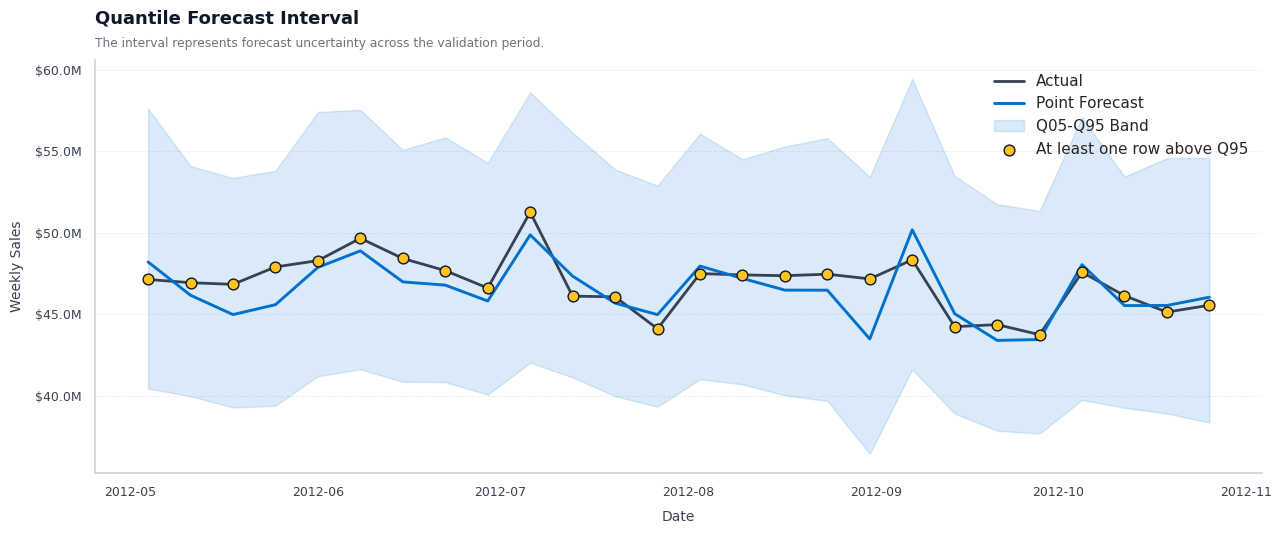

In [38]:
plot_q = quantile_frame.sort_values("Date").groupby("Date", as_index=False).agg(
    Actual=("Weekly_Sales_Clean", "sum"),
    Point=("pred_point", "sum"),
    Q05=("pred_lower", "sum"),
    Q95=("pred_upper", "sum")
)

above_dates = quantile_frame.loc[
    quantile_frame["Weekly_Sales_Clean"] > quantile_frame["pred_upper"],
    "Date"
].drop_duplicates()
plot_q["Actual_Above_Q95"] = plot_q["Date"].isin(above_dates)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(plot_q["Date"], plot_q["Actual"], color=THEME["gray_dark"], linewidth=2.0, label="Actual")
ax.plot(plot_q["Date"], plot_q["Point"], color=THEME["blue"], linewidth=2.1, label="Point Forecast")
ax.fill_between(plot_q["Date"], plot_q["Q05"], plot_q["Q95"], color=THEME["blue"], alpha=0.14, label="Q05-Q95 Band")

ax.scatter(
    plot_q.loc[plot_q["Actual_Above_Q95"], "Date"],
    plot_q.loc[plot_q["Actual_Above_Q95"], "Actual"],
    color=THEME["yellow"],
    edgecolor=THEME["slate"],
    s=60,
    zorder=4,
    label="At least one row above Q95"
)

ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Quantile Forecast Interval", "The interval represents forecast uncertainty across the validation period.")
clean_axis(ax, xlabel="Date", ylabel="Weekly Sales")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The interval chart shows aggregate demand uncertainty over time. Yellow points flag dates where at least one Store-Department row exceeded its Q95 prediction, even if the aggregate total stayed within the overall band.

Coverage is reported for all weeks, holiday weeks, and non-holiday weeks. Lower holiday coverage means the uncertainty band is not wide enough for high-risk demand periods, which supports stronger safety stock or holiday-specific interval calibration.

## 15.1 Multi-Level Interval Coverage Check

A single interval width may not be sufficient for every decision. This check evaluates empirical residual-based intervals at multiple confidence levels and reports whether holiday weeks require wider uncertainty bands than normal weeks.

In [39]:
interval_rows = []

point_col_for_interval = "pred_point" if "pred_point" in quantile_frame.columns else final_point_col
abs_residual = (quantile_frame["Weekly_Sales_Clean"] - quantile_frame[point_col_for_interval]).abs()

for level in [0.80, 0.90, 0.95]:
    half_width = abs_residual.quantile(level)
    lower = np.maximum(quantile_frame[point_col_for_interval] - half_width, 0)
    upper = quantile_frame[point_col_for_interval] + half_width
    inside = quantile_frame["Weekly_Sales_Clean"].between(lower, upper)
    holiday_mask = quantile_frame["IsHoliday"].astype(bool)

    interval_rows.append({
        "Interval_Level": level,
        "Half_Width": half_width,
        "Coverage_All": inside.mean(),
        "Coverage_Holiday": inside[holiday_mask].mean() if holiday_mask.any() else np.nan,
        "Coverage_NonHoliday": inside[~holiday_mask].mean()
    })

interval_coverage_df = pd.DataFrame(interval_rows)
pretty_table(interval_coverage_df, "Multi-Level Prediction Interval Coverage", 10)

logger.debug("Multi-level interval coverage check completed.")

,Interval_Level,Half_Width,Coverage_All,Coverage_Holiday,Coverage_NonHoliday
0,0.80,"1,741.89",0.80,0.72,0.80
1,0.90,"3,123.29",0.90,0.86,0.90
2,0.95,"4,922.95",0.95,0.93,0.95


This table shows whether wider intervals improve coverage consistently. If holiday coverage remains low even at higher interval levels, the model should use holiday-specific uncertainty calibration or stronger holiday-markdown features.

# 16. Future Forecast Generation

This section generates future-period forecasts and prepares a planning-ready forecast output. The forecast table can be used as a downstream planning input for inventory and replenishment analysis. 

In [40]:
def prepare_test_features(train_data, test_data, sd_stats, store_avg, dept_avg):
    test_core = add_core_features(test_data.copy())
    test_core["Weekly_Sales_Clean"] = np.nan

    base_cols = [col for col in test_core.columns if col in train_data.columns]

    if "Weekly_Sales_Clean" not in base_cols:
        base_cols.append("Weekly_Sales_Clean")

    base_cols = list(dict.fromkeys(base_cols))

    train_part = train_data.reindex(columns=base_cols).copy()
    test_part = test_core.reindex(columns=base_cols).copy()

    train_part = train_part.loc[:, ~train_part.columns.duplicated()].copy()
    test_part = test_part.loc[:, ~test_part.columns.duplicated()].copy()

    combined = pd.concat(
        [train_part, test_part],
        ignore_index=True,
        sort=False
    )

    combined = combined.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
    combined = add_lag_rolling_features(combined)

    test_out = combined[combined["Weekly_Sales_Clean"].isna()].copy()

    extra_cols_to_drop = [
        "StoreDept_Avg_Sales", "StoreDept_Sales_Std", "ABC_Segment",
        "Store_Avg_Sales", "Dept_Avg_Sales", "ABC_Code",
        "Store_Fuel_Avg", "Store_CPI_Avg"
    ]

    test_out = test_out.drop(
        columns=[col for col in extra_cols_to_drop if col in test_out.columns],
        errors="ignore"
    )

    test_out = test_out.merge(
        sd_stats[["Store", "Dept", "StoreDept_Avg_Sales", "StoreDept_Sales_Std", "ABC_Segment"]],
        on=["Store", "Dept"],
        how="left"
    )

    test_out = test_out.merge(store_avg, on="Store", how="left")
    test_out = test_out.merge(dept_avg, on="Dept", how="left")

    global_avg = train_data["Weekly_Sales_Clean"].mean()
    global_std = train_data["Weekly_Sales_Clean"].std()

    test_out["StoreDept_Avg_Sales"] = (
        test_out["StoreDept_Avg_Sales"]
        .fillna((test_out["Store_Avg_Sales"] + test_out["Dept_Avg_Sales"]) / 2)
        .fillna(global_avg)
    )

    test_out["StoreDept_Sales_Std"] = test_out["StoreDept_Sales_Std"].fillna(global_std)
    test_out["ABC_Segment"] = test_out["ABC_Segment"].astype("object").fillna("C")
    test_out["ABC_Code"] = test_out["ABC_Segment"].map({"A": 3, "B": 2, "C": 1}).astype(float)

    econ_ref = train_data.groupby("Store", as_index=False).agg(
        Store_Fuel_Avg=("Fuel_Price", "mean"),
        Store_CPI_Avg=("CPI", "mean")
    )

    test_out = test_out.merge(econ_ref, on="Store", how="left")
    test_out["Fuel_Relative_To_Store"] = test_out["Fuel_Price"] / test_out["Store_Fuel_Avg"]
    test_out["CPI_Relative_To_Store"] = test_out["CPI"] / test_out["Store_CPI_Avg"]

    return test_out

test_fe = prepare_test_features(data_fe, test_data, sd_stats, store_avg, dept_avg)

final_model = tuned_model if tuned_model is not None else main_model
test_X = test_fe.reindex(columns=feature_cols).fillna(global_fill)

test_fe["pred_global"] = np.maximum(final_model.predict(test_X), 0)

if "q05" in q_models:
    test_fe["pred_q05"] = np.maximum(q_models["q05"].predict(test_X), 0)
    test_fe["pred_q50"] = np.maximum(q_models["q50"].predict(test_X), 0)
    test_fe["pred_q95"] = np.maximum(q_models["q95"].predict(test_X), 0)
else:
    test_fe["pred_q50"] = test_fe["pred_global"]
    test_fe["pred_q05"] = np.maximum(
        test_fe["pred_global"] - test_fe["StoreDept_Sales_Std"].fillna(test_fe["pred_global"].median()),
        0
    )
    test_fe["pred_q95"] = test_fe["pred_global"] + test_fe["StoreDept_Sales_Std"].fillna(test_fe["pred_global"].median())

test_fe["Weekly_Sales"] = test_fe["pred_global"].clip(lower=0)

forecast_output = test_fe[["Store", "Dept", "Date", "Weekly_Sales"]].copy()

forecast_output = forecast_output.rename(columns={
    "Weekly_Sales": "Forecasted_Weekly_Sales"
})

forecast_output["Forecast_Key"] = (
    forecast_output["Store"].astype(str)
    + "_"
    + forecast_output["Dept"].astype(str)
    + "_"
    + forecast_output["Date"].dt.strftime("%Y-%m-%d")
)

forecast_output = forecast_output[
    ["Forecast_Key", "Store", "Dept", "Date", "Forecasted_Weekly_Sales"]
]

forecast_output_path = "walmart_future_forecast_output.csv"
forecast_output.to_csv(forecast_output_path, index=False)

pretty_table(forecast_output.head(10), "Future Forecast Output Preview", 10)

,Forecast_Key,Store,Dept,Date,Forecasted_Weekly_Sales
0,1_1_2012-11-02,1,1,2012-11-02 00:00:00,"37,242.97"
1,1_1_2012-11-09,1,1,2012-11-09 00:00:00,"15,104.49"
2,1_1_2012-11-16,1,1,2012-11-16 00:00:00,"15,095.76"
3,1_1_2012-11-23,1,1,2012-11-23 00:00:00,"17,438.11"
4,1_1_2012-11-30,1,1,2012-11-30 00:00:00,"16,474.38"
5,1_1_2012-12-07,1,1,2012-12-07 00:00:00,"19,188.62"
6,1_1_2012-12-14,1,1,2012-12-14 00:00:00,"17,972.67"
7,1_1_2012-12-21,1,1,2012-12-21 00:00:00,"18,703.50"
8,1_1_2012-12-28,1,1,2012-12-28 00:00:00,"17,667.02"
9,1_1_2013-01-04,1,1,2013-01-04 00:00:00,"20,608.44"


This section generates future-period forecasts and prepares a planning-ready forecast output. The same forecast table can also be used as a downstream planning input for inventory and replenishment analysis.

# 17. Forecast Diagnostics and Watchlist

Model diagnostics explain where forecasts are reliable and where they are risky. This section evaluates residuals, percentage errors, holiday behavior, markdown sensitivity, and high-risk Store-Department rows.

In [41]:
diagnostic = model_valid.copy()
diagnostic["Prediction"] = diagnostic["pred_blend"] if "pred_blend" in diagnostic.columns else diagnostic[primary_model_col]
diagnostic["Residual"] = diagnostic["Weekly_Sales_Clean"] - diagnostic["Prediction"]
diagnostic["Abs_Error"] = diagnostic["Residual"].abs()
diagnostic["Error_Rate"] = diagnostic["Abs_Error"] / diagnostic["Weekly_Sales_Clean"].replace(0, np.nan)
diagnostic["SMAPE_Row"] = np.abs(diagnostic["Weekly_Sales_Clean"] - diagnostic["Prediction"]) / ((np.abs(diagnostic["Weekly_Sales_Clean"]) + np.abs(diagnostic["Prediction"])) / 2).replace(0, np.nan)

diagnostic["Markdown_Bucket"] = pd.cut(
    diagnostic["Total_MarkDown"],
    bins=[-1, 0, diagnostic["Total_MarkDown"].quantile(0.50), diagnostic["Total_MarkDown"].quantile(0.85), np.inf],
    labels=["None", "Low-Mid", "High", "Very High"]
)

plot_sample = diagnostic.sample(min(7000, len(diagnostic)), random_state=42)
holiday_error = diagnostic.groupby("IsHoliday", as_index=False).agg(Median_Error_Rate=("Error_Rate", "median"))
holiday_error["Week Type"] = np.where(holiday_error["IsHoliday"], "Holiday", "Normal")
markdown_error = diagnostic.groupby("Markdown_Bucket", as_index=False, observed=False).agg(Median_Error_Rate=("Error_Rate", "median"))

segment_metric_rows = []
for segment in ["A", "B", "C"]:
    mask = diagnostic["ABC_Segment"].astype(str).eq(segment)
    if mask.any():
        segment_metric_rows.append({
            "Segment": segment,
            "Rows": int(mask.sum()),
            "WMAE": wmae(diagnostic.loc[mask, "Weekly_Sales_Clean"], diagnostic.loc[mask, "Prediction"], diagnostic.loc[mask, "IsHoliday"]),
            "MAE": mean_absolute_error(diagnostic.loc[mask, "Weekly_Sales_Clean"], diagnostic.loc[mask, "Prediction"]),
            "Median_Error_Rate": diagnostic.loc[mask, "Error_Rate"].median()
        })
segment_metric_df = pd.DataFrame(segment_metric_rows)

markdown_metric_rows = []
for label, mask in {"No Markdown": diagnostic["Total_MarkDown"].eq(0), "Markdown": diagnostic["Total_MarkDown"].gt(0)}.items():
    if mask.any():
        markdown_metric_rows.append({
            "Markdown Segment": label,
            "Rows": int(mask.sum()),
            "WMAE": wmae(diagnostic.loc[mask, "Weekly_Sales_Clean"], diagnostic.loc[mask, "Prediction"], diagnostic.loc[mask, "IsHoliday"]),
            "Median_Error_Rate": diagnostic.loc[mask, "Error_Rate"].median()
        })
markdown_metric_df = pd.DataFrame(markdown_metric_rows)

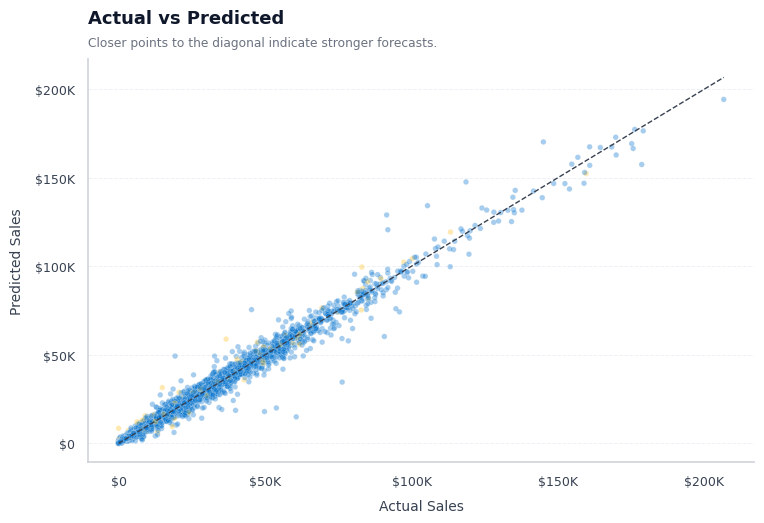

In [42]:
fig, ax = plt.subplots(figsize=(7.8, 5.4))
sns.scatterplot(data=plot_sample, x="Weekly_Sales_Clean", y="Prediction", hue="IsHoliday", palette={False: THEME["blue"], True: THEME["yellow"]}, alpha=0.35, s=16, ax=ax, legend=False)
max_val = max(plot_sample["Weekly_Sales_Clean"].max(), plot_sample["Prediction"].max())
ax.plot([0, max_val], [0, max_val], color=THEME["gray_dark"], linestyle="--", linewidth=1)
ax.xaxis.set_major_formatter(FuncFormatter(money_fmt))
ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Actual vs Predicted", "Closer points to the diagonal indicate stronger forecasts.")
clean_axis(ax, xlabel="Actual Sales", ylabel="Predicted Sales")
plt.tight_layout()
plt.show()

Actual and predicted values are closely aligned for most rows, while the largest deviations usually occur in high-sales observations where operational impact is also larger.

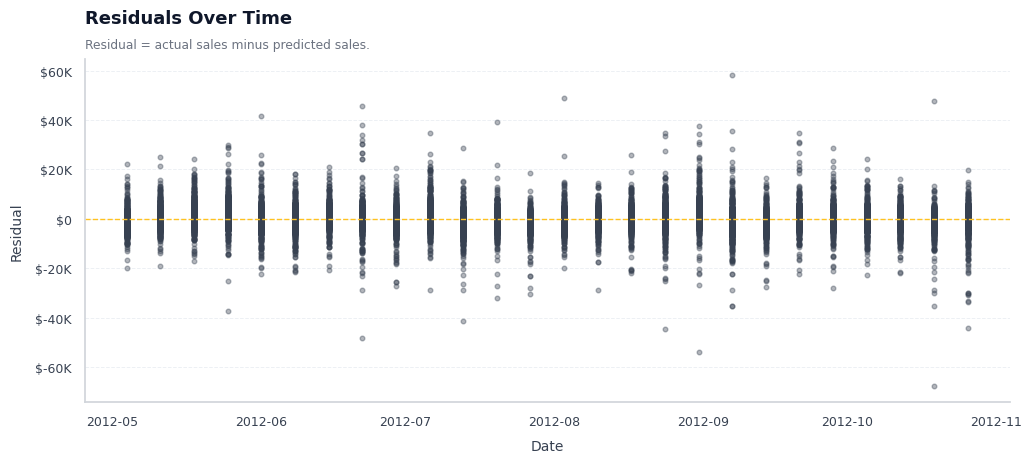

In [43]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.scatter(diagnostic["Date"], diagnostic["Residual"], color=THEME["gray_dark"], s=11, alpha=0.38)
ax.axhline(0, color=THEME["yellow"], linestyle="--", linewidth=1)
ax.yaxis.set_major_formatter(FuncFormatter(money_fmt))
set_chart_title(ax, "Residuals Over Time", "Residual = actual sales minus predicted sales.")
clean_axis(ax, xlabel="Date", ylabel="Residual")
plt.tight_layout()
plt.show()

Residuals are centered around zero, but visible spikes remain. These spikes are the main candidates for holiday, markdown, stockout, or local demand-shock review.

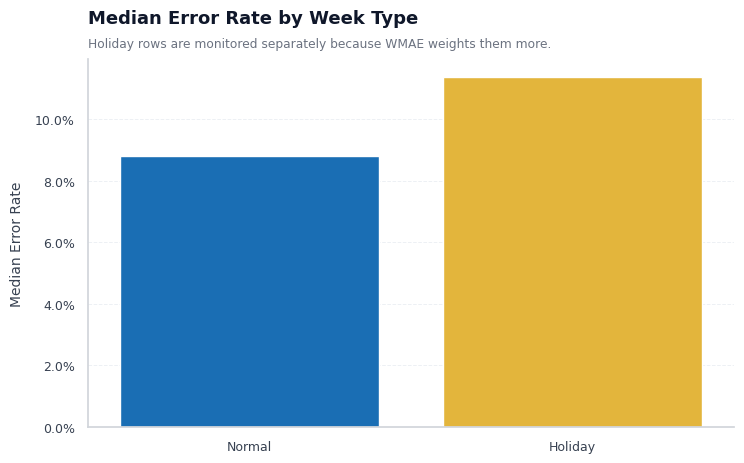

In [44]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
sns.barplot(data=holiday_error, x="Week Type", y="Median_Error_Rate", palette=[THEME["blue"], THEME["yellow"]], ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
set_chart_title(ax, "Median Error Rate by Week Type", "Holiday rows are monitored separately because WMAE weights them more.")
clean_axis(ax, xlabel="", ylabel="Median Error Rate")
plt.tight_layout()
plt.show()

Holiday weeks show a higher median error rate than normal weeks. This supports the use of holiday-specific features and separate holiday performance monitoring.

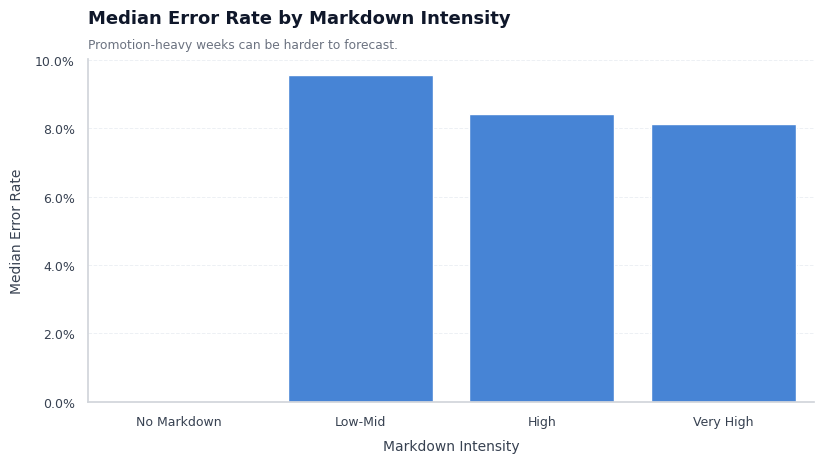

In [45]:
markdown_order = ["No Markdown", "Low-Mid", "High", "Very High"]

fig, ax = plt.subplots(figsize=(8.4, 4.8))

sns.barplot(
    data=markdown_error,
    x="Markdown_Bucket",
    y="Median_Error_Rate",
    order=markdown_order,
    color=THEME["blue_mid"],
    ax=ax
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

set_chart_title(
    ax,
    "Median Error Rate by Markdown Intensity",
    "Promotion-heavy weeks can be harder to forecast."
)

clean_axis(
    ax,
    xlabel="Markdown Intensity",
    ylabel="Median Error Rate"
)

plt.tight_layout()
plt.show()

Markdown-heavy periods remain harder to forecast. This indicates that promotion response varies across departments and should be treated as a segment-level demand signal.

In [46]:
pretty_table(segment_metric_df, "Segment-Level Error Metrics", 10)

,Segment,Rows,WMAE,MAE,Median_Error_Rate
0,A,"26,165","2,624.88","2,531.64",0.05
1,B,"19,405","1,055.39","1,005.19",0.08
2,C,"31,275",342.18,334.21,0.17


Segment-level metrics reveal whether errors are concentrated in high-volume A series or long-tail C series. This helps decide where more complex models are justified.

In [47]:
pretty_table(markdown_metric_df, "Markdown vs Non-Markdown Error Metrics", 10)

,Markdown Segment,Rows,WMAE,Median_Error_Rate
0,Markdown,"76,903","1,301.00",0.09


Markdown-specific error metrics show whether promotional weeks require dedicated monitoring, wider uncertainty intervals, or additional feature engineering.

Diagnostics now include segment-level WMAE and markdown-specific WMAE. This helps identify whether error is concentrated in high-volume, long-tail, or promotion-driven demand.

In [48]:
watchlist = diagnostic.copy()
watchlist["Risk_Level"] = pd.cut(watchlist["Error_Rate"].fillna(0), bins=[-0.01, 0.10, 0.25, 0.50, np.inf], labels=["Low", "Medium", "High", "Critical"])
watchlist_cols = ["Store", "Dept", "Date", "Weekly_Sales_Clean", "Prediction", "Abs_Error", "Error_Rate", "SMAPE_Row", "IsHoliday", "Total_MarkDown", "Markdown_Bucket", "ABC_Segment", "Risk_Level"]
watchlist_top = watchlist.sort_values(["Risk_Level", "Abs_Error"], ascending=[False, False])[watchlist_cols].head(30)
risk_summary = watchlist.groupby("Risk_Level", as_index=False, observed=True).agg(Rows=("Weekly_Sales_Clean", "size"), Avg_Actual=("Weekly_Sales_Clean", "mean"), Median_Error_Rate=("Error_Rate", "median"), Total_Abs_Error=("Abs_Error", "sum"))

In [49]:
pretty_table(watchlist_top, "Forecast Watchlist", 30)

,Store,Dept,Date,Weekly_Sales_Clean,Prediction,Abs_Error,Error_Rate,SMAPE_Row,IsHoliday,Total_MarkDown,Markdown_Bucket,ABC_Segment,Risk_Level
24613,14,72,2012-10-19 00:00:00,"69,389.31","137,111.96","67,722.65",0.98,0.66,False,"9,126.44",Low-Mid,A,Critical
21406,13,3,2012-09-07 00:00:00,"114,230.60","55,835.07","58,395.53",0.51,0.69,True,"27,193.07",Very High,A,Critical
17296,10,72,2012-08-31 00:00:00,"96,347.84","150,052.21","53,704.37",0.56,0.44,False,"42,272.28",Very High,A,Critical
37954,22,11,2012-06-22 00:00:00,"60,650.80","14,976.44","45,674.36",0.75,1.21,False,"14,877.72",High,B,Critical
24614,14,72,2012-10-26 00:00:00,"63,071.17","107,375.85","44,304.68",0.70,0.52,False,"12,398.03",High,A,Critical
60370,35,11,2012-06-01 00:00:00,"76,321.27","34,606.96","41,714.31",0.55,0.75,False,"21,378.50",High,A,Critical
33608,19,72,2012-09-07 00:00:00,"62,588.22","97,687.43","35,099.21",0.56,0.44,True,"15,625.12",High,A,Critical
60373,35,11,2012-06-22 00:00:00,"53,862.26","20,013.55","33,848.71",0.63,0.92,False,"9,182.68",Low-Mid,A,Critical
40835,23,72,2012-10-26 00:00:00,"51,421.23","85,248.50","33,827.27",0.66,0.50,False,"7,081.43",Low-Mid,A,Critical
48098,27,72,2012-10-26 00:00:00,"46,623.71","79,789.59","33,165.88",0.71,0.52,False,"10,969.27",Low-Mid,A,Critical


The watchlist surfaces the most exposed Store-Department-Date rows. These rows should be reviewed first because they combine high absolute error with high operational relevance.

In [50]:
pretty_table(risk_summary, "Forecast Risk Summary", 10)

,Risk_Level,Rows,Avg_Actual,Median_Error_Rate,Total_Abs_Error
0,Low,"41,586","21,930.03",0.04,"36,319,669.66"
1,Medium,"20,884","12,023.57",0.15,"38,202,389.78"
2,High,"7,733","6,199.33",0.33,"15,883,973.32"
3,Critical,"6,700","1,154.57",1.22,"5,974,033.42"


The risk summary translates row-level forecast errors into a compact distribution of low, medium, high, and critical cases.

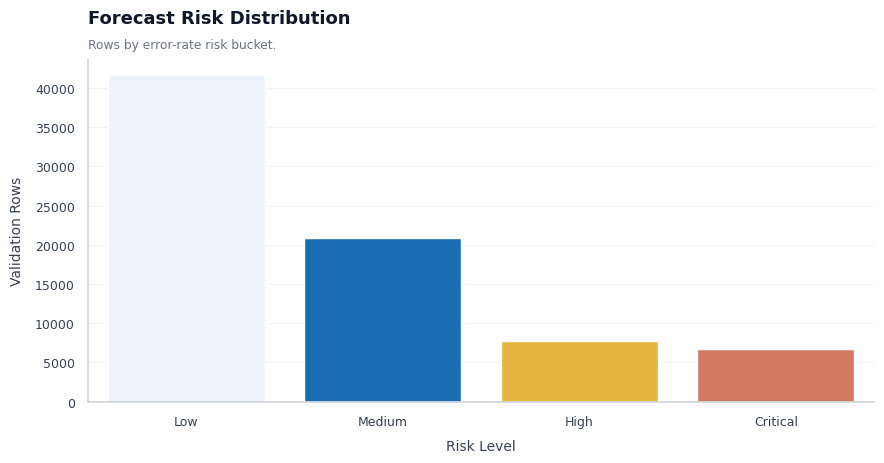

In [51]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=risk_summary, x="Risk_Level", y="Rows", palette=[THEME["blue_soft"], THEME["blue"], THEME["yellow"], THEME["danger"]], ax=ax)
set_chart_title(ax, "Forecast Risk Distribution", "Rows by error-rate risk bucket.")
clean_axis(ax, xlabel="Risk Level", ylabel="Validation Rows")
plt.tight_layout()
plt.show()

Most operational attention should be directed to high and critical buckets, especially when they overlap with holiday weeks, markdown periods, or A-segment Store-Department pairs.

The watchlist identifies rows where the model is most exposed. High-error and high-volume rows should be investigated first because they carry the largest planning and inventory risk.

## 17.1 Paired Error Comparison

Model scores can look different even when the row-level improvement is not consistent. This lightweight paired comparison checks whether the selected forecasting model reduces absolute error against the strongest baseline on the same validation rows. It is not a replacement for a full statistical forecasting study, but it adds a useful robustness check without making the notebook unnecessarily complex.

In [52]:
from scipy.stats import norm

comparison_model_col = "pred_blend" if "pred_blend" in model_valid.columns else primary_model_col

baseline_col_map = {
    "Naive Lag-1": "pred_lag1",
    "Moving Average 4": "pred_ma4",
    "Moving Average 8": "pred_ma8",
    "Moving Average 12": "pred_ma12",
    "Seasonal Naive 52": "pred_seasonal52"
}

if "baseline_eval_df" in globals() and len(baseline_eval_df) > 0:
    baseline_name = baseline_eval_df.sort_values("WMAE").iloc[0]["Model"]
    baseline_col = baseline_col_map.get(baseline_name, "pred_ma4")
else:
    baseline_name = "Moving Average 4"
    baseline_col = "pred_ma4"

if baseline_col not in valid_base.columns:
    baseline_col = "pred_ma4" if "pred_ma4" in valid_base.columns else valid_base.select_dtypes(include=np.number).columns[0]

paired_frame = model_valid[["Weekly_Sales_Clean", comparison_model_col, "IsHoliday"]].copy()

paired_frame["Baseline"] = (
    valid_base
    .reindex(model_valid.index)[baseline_col]
)

paired_frame = paired_frame.dropna(
    subset=["Baseline", comparison_model_col, "Weekly_Sales_Clean"]
)

paired_frame["Model_Abs_Error"] = (
    paired_frame["Weekly_Sales_Clean"] - paired_frame[comparison_model_col]
).abs()

paired_frame["Baseline_Abs_Error"] = (
    paired_frame["Weekly_Sales_Clean"] - paired_frame["Baseline"]
).abs()

paired_frame["Error_Difference"] = (
    paired_frame["Baseline_Abs_Error"] - paired_frame["Model_Abs_Error"]
)

n = len(paired_frame)
mean_diff = paired_frame["Error_Difference"].mean()
std_diff = paired_frame["Error_Difference"].std(ddof=1)

if n > 1 and std_diff > 0:
    z_stat = mean_diff / (std_diff / np.sqrt(n))
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
else:
    z_stat = np.nan
    p_value = np.nan

paired_summary = pd.DataFrame({
    "Comparison": [f"{comparison_model_col} vs {baseline_name}"],
    "Rows": [n],
    "Mean_Error_Reduction": [mean_diff],
    "Share_Model_Better": [(paired_frame["Error_Difference"] > 0).mean()],
    "Approx_Z": [z_stat],
    "Approx_P_Value": [p_value]
})

pretty_table(
    paired_summary,
    "Paired Absolute Error Comparison",
    5,
    color_cols=["Mean_Error_Reduction", "Share_Model_Better"]
)

,Comparison,Rows,Mean_Error_Reduction,Share_Model_Better,Approx_Z,Approx_P_Value
0,pred_blend vs Moving Average 4,"76,885",309.86,0.54,40.37,0.00


A positive mean error reduction means the selected model lowers absolute error compared with the strongest baseline on the same rows. If the p-value is high, the improvement should be interpreted cautiously and validated with additional time windows.

# 18. Inventory Action Layer

Forecasting is useful only if it supports operational decisions. This section translates forecast error, uncertainty, and risk level into inventory-oriented actions.

In [53]:
inventory_view = watchlist.copy()

if "quantile_frame" in globals() and {"pred_q05", "pred_q95"}.issubset(quantile_frame.columns):
    q_cols = quantile_frame[["Store", "Dept", "Date", "pred_q05", "pred_q95"]].copy()
    inventory_view = inventory_view.merge(q_cols, on=["Store", "Dept", "Date"], how="left")
    inventory_view["Interval_Width"] = inventory_view["pred_q95"] - inventory_view["pred_q05"]
else:
    inventory_view["pred_q05"] = np.nan
    inventory_view["pred_q95"] = np.nan
    inventory_view["Interval_Width"] = np.nan

inventory_view["Relative_Interval_Width"] = inventory_view["Interval_Width"] / inventory_view["Prediction"].replace(0, np.nan)
median_width = inventory_view["Relative_Interval_Width"].median()
if pd.isna(median_width):
    median_width = 0

inventory_view["Inventory_Risk"] = pd.cut(inventory_view["Relative_Interval_Width"].fillna(median_width), bins=[-np.inf, 0.20, 0.50, np.inf], labels=["Low", "Medium", "High"]).astype(str)

inventory_view["Inventory_Action"] = np.select(
    [
        inventory_view["Inventory_Risk"].eq("High") & inventory_view["IsHoliday"].astype(bool),
        inventory_view["Inventory_Risk"].eq("High") & inventory_view["Total_MarkDown"].gt(0),
        inventory_view["Inventory_Risk"].eq("Medium"),
        inventory_view["Inventory_Risk"].eq("Low")
    ],
    [
        "Pre-build safety stock before holiday demand",
        "Review promotion allocation and increase buffer",
        "Use standard replenishment with weekly review",
        "Maintain lean replenishment"
    ],
    default="Standard review"
)

inventory_summary = inventory_view.groupby(["Inventory_Risk", "Inventory_Action"], as_index=False, observed=True).agg(Rows=("Store", "count"), Median_Error_Rate=("Error_Rate", "median"), Median_Relative_Width=("Relative_Interval_Width", "median"), Total_Abs_Error=("Abs_Error", "sum"))
risk_order = {"High": 3, "Medium": 2, "Low": 1}
inventory_summary["Risk_Order"] = inventory_summary["Inventory_Risk"].map(risk_order).fillna(0)
inventory_summary = inventory_summary.sort_values(["Risk_Order", "Total_Abs_Error"], ascending=[False, False]).drop(columns="Risk_Order").reset_index(drop=True)

inventory_view["Risk_Order"] = inventory_view["Inventory_Risk"].map(risk_order).fillna(0)
inventory_watchlist = inventory_view.sort_values(["Risk_Order", "Abs_Error"], ascending=[False, False]).head(25).drop(columns="Risk_Order")
watchlist_cols = ["Store", "Dept", "Date", "Weekly_Sales_Clean", "Prediction", "Abs_Error", "Error_Rate", "pred_q05", "pred_q95", "Inventory_Risk", "Inventory_Action"]
watchlist_cols = [col for col in watchlist_cols if col in inventory_watchlist.columns]

In [54]:
pretty_table(inventory_summary, "Inventory Risk and Action Summary", 20)

,Inventory_Risk,Inventory_Action,Rows,Median_Error_Rate,Median_Relative_Width,Total_Abs_Error
0,High,Review promotion allocation and increase buffer,"30,417",0.19,0.79,"27,561,474.42"
1,High,Pre-build safety stock before holiday demand,"1,132",0.28,0.77,"1,585,142.58"
2,Medium,Use standard replenishment with weekly review,"36,228",0.07,0.35,"52,974,771.88"
3,Low,Maintain lean replenishment,"9,126",0.03,0.16,"14,258,677.30"


Inventory risk combines forecast uncertainty and observed error behavior. High-risk rows require stronger safety-stock or promotion allocation review.

In [55]:
pretty_table(inventory_watchlist[watchlist_cols], "Inventory Watchlist", 25)

,Store,Dept,Date,Weekly_Sales_Clean,Prediction,Abs_Error,Error_Rate,pred_q05,pred_q95,Inventory_Risk,Inventory_Action
24613,14,72,2012-10-19 00:00:00,"69,389.31","137,111.96","67,722.65",0.98,"65,545.53","278,135.49",High,Review promotion allocation and increase buffer
21406,13,3,2012-09-07 00:00:00,"114,230.60","55,835.07","58,395.53",0.51,"30,439.28","83,323.89",High,Pre-build safety stock before holiday demand
17296,10,72,2012-08-31 00:00:00,"96,347.84","150,052.21","53,704.37",0.56,"93,763.42","229,908.33",High,Review promotion allocation and increase buffer
15945,10,3,2012-08-03 00:00:00,"120,827.95","71,761.82","49,066.13",0.41,"38,069.77","103,301.35",High,Review promotion allocation and increase buffer
27077,16,9,2012-10-19 00:00:00,"111,246.19","63,327.87","47,918.32",0.43,"22,102.00","77,289.93",High,Review promotion allocation and increase buffer
37954,22,11,2012-06-22 00:00:00,"60,650.80","14,976.44","45,674.36",0.75,"11,553.25","21,460.48",High,Review promotion allocation and increase buffer
24614,14,72,2012-10-26 00:00:00,"63,071.17","107,375.85","44,304.68",0.70,"63,204.43","274,061.14",High,Review promotion allocation and increase buffer
60370,35,11,2012-06-01 00:00:00,"76,321.27","34,606.96","41,714.31",0.55,"15,342.67","66,581.71",High,Review promotion allocation and increase buffer
39718,23,11,2012-06-22 00:00:00,"78,530.70","40,639.43","37,891.27",0.48,"30,432.29","53,820.49",High,Review promotion allocation and increase buffer
21405,13,3,2012-08-31 00:00:00,"91,139.25","53,432.17","37,707.08",0.41,"26,003.25","69,882.74",High,Review promotion allocation and increase buffer


The inventory watchlist turns forecast diagnostics into replenishment priorities. Rows with wide intervals, high error rates, holiday flags, or markdown exposure should be reviewed before ordering decisions.

Inventory guidance is now linked to forecast interval width. Wider intervals indicate demand uncertainty and justify stronger safety-stock or replenishment review.

# 19. Production Readiness and Reproducibility Layer

This section does not change the modelling logic; it prepares the notebook for a more production-like workflow. The goal is to make configuration, model artifacts, critical function checks, and batch prediction repeatable. In a full repository, the exported functions can be moved into `data_loader.py`, `features.py`, `models.py`, `evaluation.py`, and `visualization.py`.

In [56]:
MODULE_DIR = ARTIFACT_DIR / "module_templates"
MODULE_DIR.mkdir(parents=True, exist_ok=True)

module_templates = {
    "evaluation.py": '''import numpy as np

def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)
''',
    "features.py": '''def add_core_features(df, markdown_cols):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["Date"].dt.quarter
    df["Total_MarkDown"] = df[markdown_cols].fillna(0).sum(axis=1)
    df["Has_MarkDown"] = (df["Total_MarkDown"] > 0).astype(int)
    return df
''',
    "config.py": f'''PROJECT_CONFIG = {repr(PROJECT_CONFIG)}
'''
}

for filename, content in module_templates.items():
    with open(MODULE_DIR / filename, "w", encoding="utf-8") as f:
        f.write(content)

logger.debug("Module templates exported.")

## 19.1 Critical Function Smoke Tests

These checks are not a substitute for a full unit-test suite, but they verify that key functions behave as expected before the notebook exports artifacts or runs batch predictions.

In [57]:
def run_smoke_tests():
    assert round(wmae([100, 100], [90, 110], [False, True]), 6) == 10.0

    sample = pd.DataFrame({
        "Store": [1, 1, 1, 1, 1],
        "Dept": [1, 1, 1, 1, 1],
        "Date": pd.date_range("2020-01-03", periods=5, freq="W-FRI"),
        "Weekly_Sales_Clean": [10, 12, 14, 16, 18]
    })

    lagged = add_lag_rolling_features(sample)

    assert "lag_1" in lagged.columns
    assert pd.isna(lagged.loc[0, "lag_1"])
    assert lagged.loc[1, "lag_1"] == 10

    ordered_dates = np.array(sorted(data_fe["Date"].dropna().unique()))

    if len(ordered_dates) >= 10:
        validation_dates = ordered_dates[-4:]
        train_dates = ordered_dates[:-4]

        train_idx = data_fe.index[data_fe["Date"].isin(train_dates)].tolist()
        valid_idx = data_fe.index[data_fe["Date"].isin(validation_dates)].tolist()

        splits = [(train_idx, valid_idx)]
    else:
        splits = []

    assert isinstance(splits, list)

    if len(splits) > 0:
        assert len(splits[0]) == 2
        assert len(splits[0][0]) > 0
        assert len(splits[0][1]) > 0

    return "Smoke tests passed"


smoke_test_result = run_smoke_tests()

pretty_table(
    pd.DataFrame({"Check": [smoke_test_result]}),
    "Production Readiness Checks",
    5
)

,Check
0,Smoke tests passed


## 19.2 Model Artifact Export

The best available model, feature list, fill values, tuning results, and configuration are saved as reproducible artifacts. This makes the notebook output usable for downstream scoring, review, or deployment experiments.

In [58]:
artifact_manifest = {
    "config_path": str(ARTIFACT_DIR / "config.json"),
    "feature_count": len(feature_cols) if "feature_cols" in globals() else 0,
    "joblib_available": joblib_available
}

best_available_model = None
if "tuned_model" in globals() and tuned_model is not None:
    best_available_model = tuned_model
    artifact_manifest["best_model"] = "tuned_model"
elif "main_model" in globals():
    best_available_model = main_model
    artifact_manifest["best_model"] = "main_model"
else:
    artifact_manifest["best_model"] = "not_available"

if joblib_available and best_available_model is not None:
    joblib.dump(best_available_model, ARTIFACT_DIR / "best_forecast_model.pkl")
    joblib.dump(feature_cols, ARTIFACT_DIR / "feature_columns.pkl")
    joblib.dump(global_fill, ARTIFACT_DIR / "global_fill_values.pkl")

if "tuning_df" in globals():
    tuning_df.to_csv(ARTIFACT_DIR / "tuning_results.csv", index=False)

if "leaderboard" in globals():
    leaderboard.to_csv(ARTIFACT_DIR / "model_leaderboard.csv", index=False)

with open(ARTIFACT_DIR / "artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest, f, indent=2)

pretty_table(pd.DataFrame([artifact_manifest]), "Artifact Export Manifest", 5)
logger.debug("Model artifacts exported.")

,config_path,feature_count,joblib_available,best_model
0,walmart_artifacts/config.json,58,True,tuned_model


## 19.3 Batch Prediction Interface

The following function provides a reusable scoring interface for new Walmart-style weekly rows. It applies the same test-feature preparation logic and returns store-department-date predictions without requiring users to manually repeat the feature steps.

In [59]:
def batch_predict(new_test_data, trained_model=None):
    model_to_use = trained_model
    if model_to_use is None:
        if "tuned_model" in globals() and tuned_model is not None:
            model_to_use = tuned_model
        elif "main_model" in globals():
            model_to_use = main_model
        else:
            raise ValueError("No trained model is available for batch prediction.")

    prepared = prepare_test_features(
        data_fe,
        new_test_data.copy(),
        sd_stats,
        store_avg,
        dept_avg
    )

    X_new = prepared.reindex(columns=feature_cols).fillna(global_fill)
    prepared["Prediction"] = np.maximum(model_to_use.predict(X_new), 0)

    return prepared[["Store", "Dept", "Date", "Prediction"]]

batch_preview = batch_predict(test_data.head(20))
pretty_table(batch_preview.head(10), "Batch Prediction Preview", 10)
logger.debug("Batch prediction interface validated.")

,Store,Dept,Date,Prediction
0,1,1,2012-11-02 00:00:00,"37,242.97"
1,1,1,2012-11-09 00:00:00,"15,104.49"
2,1,1,2012-11-16 00:00:00,"15,095.76"
3,1,1,2012-11-23 00:00:00,"17,438.11"
4,1,1,2012-11-30 00:00:00,"16,474.38"
5,1,1,2012-12-07 00:00:00,"19,188.62"
6,1,1,2012-12-14 00:00:00,"17,972.67"
7,1,1,2012-12-21 00:00:00,"18,703.50"
8,1,1,2012-12-28 00:00:00,"17,667.02"
9,1,1,2013-01-04 00:00:00,"20,608.44"


The production-readiness layer adds repeatability without changing the analytical story. Configuration is exported, critical functions are smoke-tested, model artifacts are saved, and a batch prediction function is available for future scoring.

# 20. Key Findings and Business Outcomes

In [60]:
key_findings = pd.DataFrame({
    "Area": [
        "Demand Behavior",
        "Historical Sales Signal",
        "Model Performance",
        "Uncertainty Management",
        "Inventory Action"
    ],
    "Key Finding": [
        "Weekly sales vary by store, department, holiday period, and markdown activity.",
        "Lag and rolling features provide strong forecasting signals from recent and seasonal sales history.",
        "The machine learning model builds on baseline rules by using calendar, markdown, economic, and Store-Department features.",
        "Quantile forecasting adds lower and upper demand ranges, making the forecast more useful for risk-aware planning.",
        "Forecast outputs are translated into safety stock, buffer, promotion allocation review, and replenishment decisions."
    ]
})

pretty_table(
    key_findings,
    "Key Findings and Business Outcomes",
    10,
    color_cols=[]
)

,Area,Key Finding
0,Demand Behavior,"Weekly sales vary by store, department, holiday period, and markdown activity."
1,Historical Sales Signal,Lag and rolling features provide strong forecasting signals from recent and seasonal sales history.
2,Model Performance,"The machine learning model builds on baseline rules by using calendar, markdown, economic, and Store-Department features."
3,Uncertainty Management,"Quantile forecasting adds lower and upper demand ranges, making the forecast more useful for risk-aware planning."
4,Inventory Action,"Forecast outputs are translated into safety stock, buffer, promotion allocation review, and replenishment decisions."


Overall, this project shows that Walmart weekly sales forecasting is not only a prediction task. 
The analysis reveals how demand changes across stores, departments, holiday periods, and markdown activity. 
Historical sales signals, especially lag and rolling features, provide a strong forecasting foundation. 
The machine learning model strengthens this foundation with calendar, economic, promotional, and Store-Department features. 
Quantile forecasting adds uncertainty ranges, and the inventory action layer translates forecast risk into practical stock planning decisions.

# 21. Executive Conclusions

This notebook builds a complete Walmart store sales forecasting workflow from data understanding to model diagnostics and inventory-oriented decision support.

The project shows that weekly sales should not be treated as one aggregated time series. Demand behavior changes by Store, Department, holiday timing, markdown intensity, and historical sales contribution. The strongest forecasting setup therefore combines several layers:

- **Reference performance:** naive, moving-average, and seasonal-naive baselines define the minimum standard that any advanced model should beat.
- **Interpretability:** Prophet and SARIMA are used on a representative Store-Department series to explain trend, seasonality, and benchmark behavior.
- **Main forecasting performance:** the global machine-learning model uses calendar, lag, rolling, markdown, economic, and historical Store-Department signals across the full dataset.
- **Segment strategy:** ABC segmentation helps identify whether high-volume and long-tail Store-Department groups need different modeling complexity.
- **Uncertainty management:** quantile intervals expose where forecasts are less certain, especially around holiday and markdown periods.
- **Inventory action layer:** high-error, high-uncertainty, holiday, and markdown-sensitive rows are translated into replenishment and safety-stock review priorities.

From a business perspective, the most important output is not only the final prediction. The diagnostics identify where demand risk is concentrated and where planners should intervene. High-risk holiday or promotion rows may require pre-built safety stock, while stable low-risk rows can remain on lean replenishment. This makes the workflow useful both as a forecasting model and as a demand-risk monitoring framework.

For future scaling, the tuned global model can remain the primary forecasting layer, baseline forecasts can be retained as fallback controls, and segment models can be used selectively where they improve validation performance. This keeps the forecasting stack disciplined while preserving flexibility for high-value Store-Department segments.

<div style="
  background: linear-gradient(to right, #f8fafc, #eff6ff);
  padding: 25px;
  border-radius: 12px;
  color: #1e293b;
  font-family: 'Segoe UI', Roboto, Arial, sans-serif;
  font-size: 16px;
  line-height: 1.7;
  box-shadow: 0 4px 15px rgba(15,23,42,0.08);
  margin-top: 30px;
  border: 1px solid #cbd5e1;
">

  <h2 style="color: #0071CE; margin-top: 0; display: flex; align-items: center; gap: 10px;">
    💙 Support & Feedback
  </h2>

  <p>
    If this <strong>Walmart Retail Forecasting</strong> notebook helped you understand demand patterns,
    evaluate forecast risk, or connect machine learning outputs to inventory planning, you can support this work by:
  </p>

  <ul style="list-style-type: none; padding-left: 5px;">
    <li style="margin-bottom: 10px;">⭐ <strong>Upvoting</strong> the notebook to improve its visibility for the retail analytics and forecasting community</li>
    <li style="margin-bottom: 10px;">💬 <strong>Leaving a comment</strong> — sharing your thoughts, modelling suggestions, or ideas for improving holiday and markdown forecasting</li>
    <li style="margin-bottom: 10px;">🔁 <strong>Forking</strong> the project to test new features, tune alternative models, expand quantile forecasting, or build stronger inventory simulations</li>
  </ul>

  <p>
    Your engagement helps keep this kind of open, decision-focused retail analytics work evolving —
    from <strong>demand forecasting</strong> to <strong>inventory risk intelligence</strong>. 💡
  </p>

  <blockquote style="
    background-color: #fff8db;
    border-left: 5px solid #FFC220;
    padding: 15px 20px;
    margin-top: 20px;
    font-style: italic;
    color: #713f12;
    border-radius: 0 8px 8px 0;">
    Forecast clearly, measure uncertainty carefully, and turn demand signals into smarter replenishment decisions. 🛒📦📈
  </blockquote>

</div>